### Exploratory Data Analysis


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
from datetime import datetime

warnings.filterwarnings("ignore")


#### Kustomisasi Style Grafik


In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f8f9fa",
        "axes.edgecolor": "#cccccc",
        "axes.labelcolor": "#333333",
        "axes.titlecolor": "#111111",
        "xtick.color": "#555555",
        "ytick.color": "#555555",
        "text.color": "#333333",
        "grid.color": "#dddddd",
        "grid.linestyle": "--",
        "grid.alpha": 0.7,
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

PALETTE = [
    "#6c63ff",
    "#ff6584",
    "#43e97b",
    "#f7971e",
    "#4facfe",
    "#fa709a",
    "#a18cd1",
    "#fda085",
    "#30cfd0",
    "#667eea",
]
GRADIENT = plt.cm.get_cmap("plasma")

BASE_DIR = "."
OUTPUT_DIR = os.path.join(BASE_DIR, "For_Dashboard")
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIGURES_DIR = os.path.join(BASE_DIR, "EDA_Figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_fig(name, dpi=150):
    path = os.path.join(FIGURES_DIR, f"{name}.png")
    plt.savefig(
        path, dpi=dpi, bbox_inches="tight", facecolor="white"
    )
    plt.show() # Display inline in notebook!
    print(f"Saved: {name}.png")

def fmt_idr(x, _=None):
    if x >= 1e12:
        return f"Rp {x/1e12:.1f}T"
    if x >= 1e9:
        return f"Rp {x/1e9:.1f}B"
    if x >= 1e6:
        return f"Rp {x/1e6:.0f}M"
    return f"Rp {x:,.0f}"


#### Bagian 1 – Load Data


In [102]:
df_CA = pd.read_csv(os.path.join(BASE_DIR, "table_CA_new.csv"))
df_sell_in = pd.read_csv(os.path.join(BASE_DIR, "table_sell_in_new.csv"))
df_sell_out = pd.read_csv(os.path.join(BASE_DIR, "table_sell_out_new.csv"))
df_survey = pd.read_csv(os.path.join(BASE_DIR, "table_survey_new.csv"))

# Date parsing
df_CA["tanggal_trx"] = pd.to_datetime(df_CA["tanggal_trx"], errors="coerce")
df_sell_in["date"] = pd.to_datetime(df_sell_in["date"], errors="coerce")
df_sell_out["tanggal_trx"] = pd.to_datetime(df_sell_out["tanggal_trx"], errors="coerce")
df_survey["visit_date"] = pd.to_datetime(df_survey["visit_date"], errors="coerce")

# Derived time columns
for df, col in [
    (df_CA, "tanggal_trx"),
    (df_sell_in, "date"),
    (df_sell_out, "tanggal_trx"),
    (df_survey, "visit_date"),
]:
    df["year_month"] = df[col].dt.to_period("M").astype(str)
    df["month"] = df[col].dt.month
    df["year"] = df[col].dt.year

print(f"\n  CA:      {df_CA.shape[0]:>7,} rows × {df_CA.shape[1]} cols")
print(f"  Sell-In: {df_sell_in.shape[0]:>7,} rows × {df_sell_in.shape[1]} cols")
print(f"  Sell-Out:{df_sell_out.shape[0]:>7,} rows × {df_sell_out.shape[1]} cols")
print(f"  Survey:  {df_survey.shape[0]:>7,} rows × {df_survey.shape[1]} cols")



  CA:       15,383 rows × 33 cols
  Sell-In:  15,439 rows × 27 cols
  Sell-Out: 49,167 rows × 12 cols
  Survey:    8,350 rows × 39 cols


#### Bagian 2 – Melihat Struktur Data


In [103]:
datasets = {
    "CA (table_CA_new)": df_CA,
    "Sell-In (table_sell_in_new)": df_sell_in,
    "Sell-Out (table_sell_out_new)": df_sell_out,
    "Survey (table_survey_new)": df_survey,
}

quality_rows = []
for name, df in datasets.items():
    mv = df.isnull().sum().sum()
    dup = df.duplicated().sum()
    quality_rows.append(
        {
            "Dataset": name,
            "Rows": df.shape[0],
            "Cols": df.shape[1],
            "Missing Values": mv,
            "Missing %": f"{100*mv/(df.shape[0]*df.shape[1]):.2f}%",
            "Duplicate Rows": dup,
            "Duplicate %": f"{100*dup/df.shape[0]:.2f}%",
        }
    )
    print(f"\n  ── {name}")
    print(f"     Shape: {df.shape}")
    print(f"     Missing values: {mv} ({100*mv/(df.shape[0]*df.shape[1]):.2f}%)")
    print(f"     Duplicate rows: {dup}")
    print(
        f"     Date range: {df.select_dtypes('datetime64[ns]').iloc[:,0].min().date()} → "
        f"{df.select_dtypes('datetime64[ns]').iloc[:,0].max().date()}"
    )

quality_df = pd.DataFrame(quality_rows)
print("\n", quality_df.to_string(index=False))



  ── CA (table_CA_new)
     Shape: (15383, 33)
     Missing values: 0 (0.00%)
     Duplicate rows: 0
     Date range: 2026-01-01 → 2026-12-31

  ── Sell-In (table_sell_in_new)
     Shape: (15439, 27)
     Missing values: 0 (0.00%)
     Duplicate rows: 0
     Date range: 2026-01-01 → 2026-12-31

  ── Sell-Out (table_sell_out_new)
     Shape: (49167, 12)
     Missing values: 0 (0.00%)
     Duplicate rows: 0
     Date range: 2026-01-01 → 2026-12-31

  ── Survey (table_survey_new)
     Shape: (8350, 39)
     Missing values: 0 (0.00%)
     Duplicate rows: 0
     Date range: 2026-01-01 → 2026-12-31

                       Dataset  Rows  Cols  Missing Values Missing %  Duplicate Rows Duplicate %
            CA (table_CA_new) 15383    33               0     0.00%               0       0.00%
  Sell-In (table_sell_in_new) 15439    27               0     0.00%               0       0.00%
Sell-Out (table_sell_out_new) 49167    12               0     0.00%               0       0.00%
    Survey (t

#### Bagian 3 – Analisis Outlier


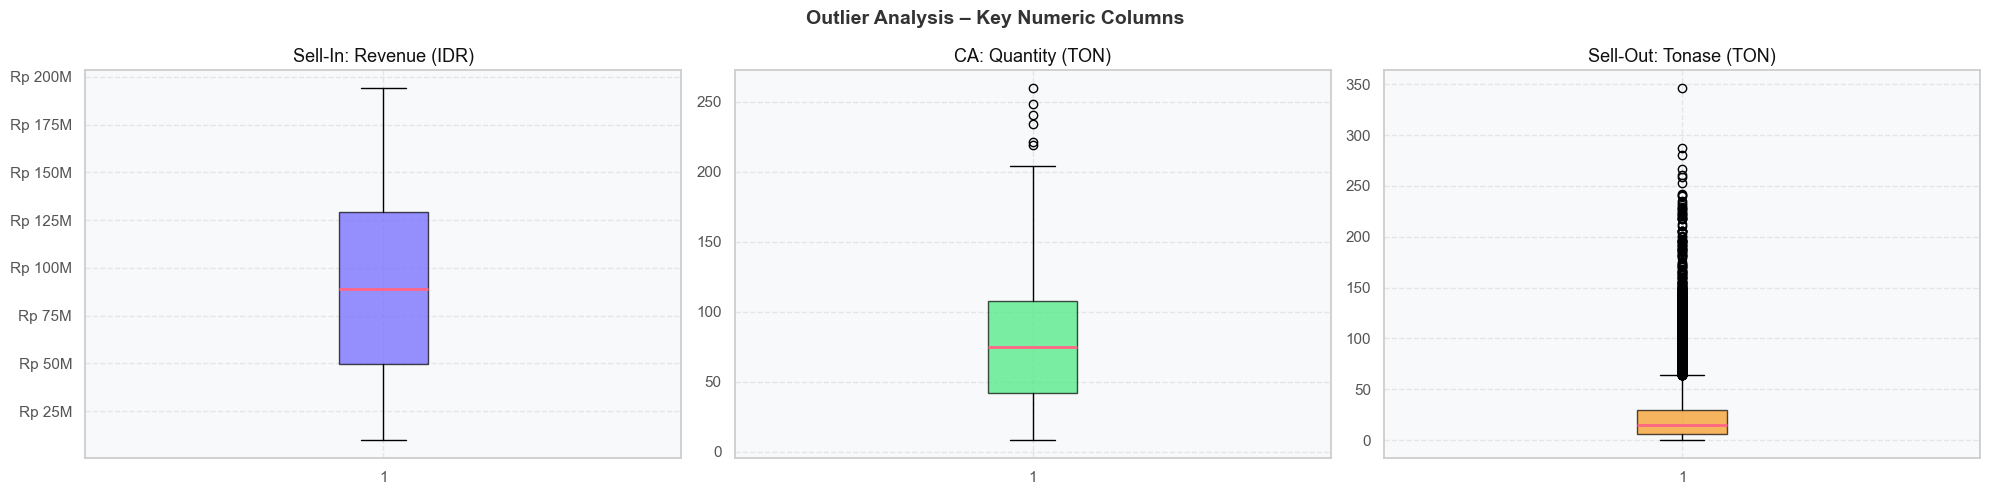

Saved: 02_outlier_analysis.png

  Sell-In Revenue Outliers: 0 rows (0.0%)
  Revenue range: Rp 10M → Rp 194M
  Revenue mean:  Rp 90M


In [104]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Outlier Analysis – Key Numeric Columns", fontsize=14, fontweight="bold")

# Sell-In revenue
axes[0].boxplot(
    df_sell_in["revenue"].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="#6c63ff", alpha=0.7),
    medianprops=dict(color="#ff6584", lw=2),
)
axes[0].set_title("Sell-In: Revenue (IDR)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_idr))

# CA quantity
axes[1].boxplot(
    df_CA["quantity"].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="#43e97b", alpha=0.7),
    medianprops=dict(color="#ff6584", lw=2),
)
axes[1].set_title("CA: Quantity (TON)")

# Sell-Out tonase
axes[2].boxplot(
    df_sell_out["sum(tonase)"].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="#f7971e", alpha=0.7),
    medianprops=dict(color="#ff6584", lw=2),
)
axes[2].set_title("Sell-Out: Tonase (TON)")

plt.tight_layout()
save_fig("02_outlier_analysis")

# Revenue outlier stats
Q1 = df_sell_in["revenue"].quantile(0.25)
Q3 = df_sell_in["revenue"].quantile(0.75)
IQR = Q3 - Q1
outliers_rev = df_sell_in[
    (df_sell_in["revenue"] < Q1 - 1.5 * IQR) | (df_sell_in["revenue"] > Q3 + 1.5 * IQR)
]
print(
    f"\n  Sell-In Revenue Outliers: {len(outliers_rev):,} rows ({100*len(outliers_rev)/len(df_sell_in):.1f}%)"
)
print(
    f"  Revenue range: {fmt_idr(df_sell_in['revenue'].min())} → {fmt_idr(df_sell_in['revenue'].max())}"
)
print(f"  Revenue mean:  {fmt_idr(df_sell_in['revenue'].mean())}")


#### Bagian 4 – Analisis Revenue


##### 4.1 Tren Revenue Bulanan


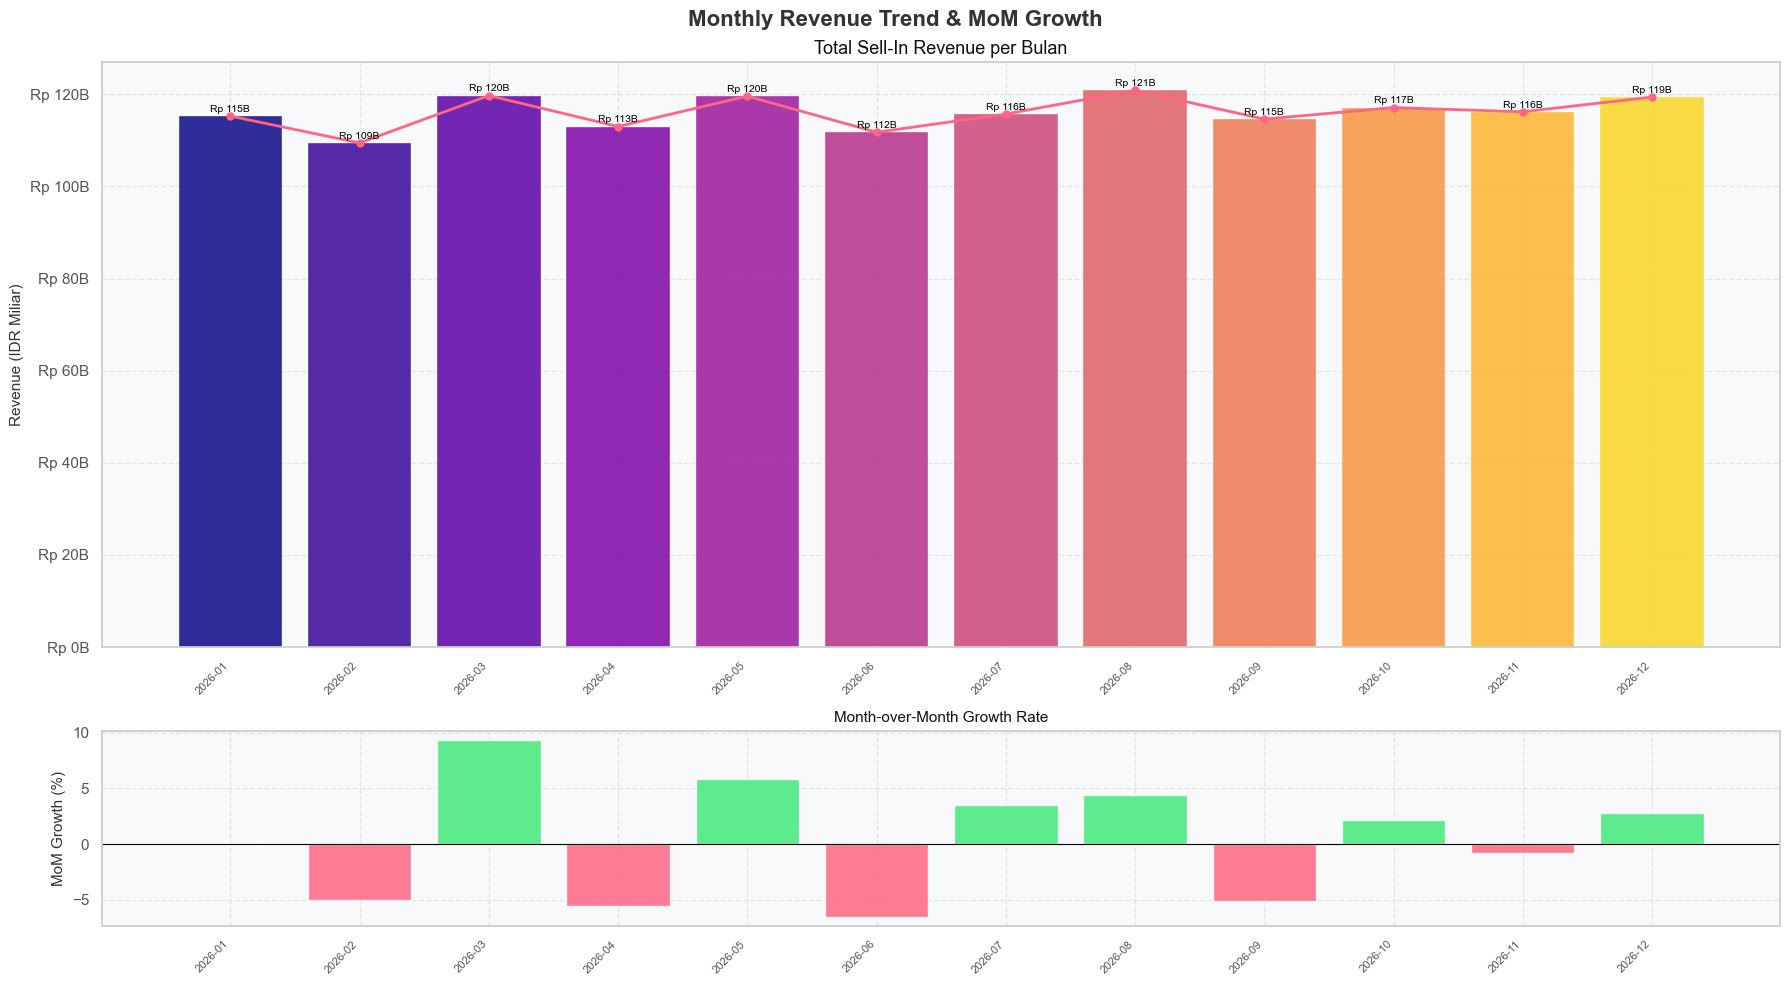

Saved: 03_revenue_monthly_trend.png


In [105]:
rev_monthly = df_sell_in.groupby("year_month")["revenue"].sum().reset_index()
rev_monthly = rev_monthly.sort_values("year_month")
rev_monthly["revenue_B"] = rev_monthly["revenue"] / 1e9
rev_monthly["MoM_growth"] = rev_monthly["revenue"].pct_change() * 100

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(18, 10), gridspec_kw={"height_ratios": [3, 1]}
)
fig.suptitle("Monthly Revenue Trend & MoM Growth", fontsize=16, fontweight="bold")

colors = [GRADIENT(i / len(rev_monthly)) for i in range(len(rev_monthly))]
bars = ax1.bar(
    rev_monthly["year_month"],
    rev_monthly["revenue_B"],
    color=colors,
    alpha=0.85,
    edgecolor="white",
    lw=0.3,
)
ax1.plot(
    rev_monthly["year_month"],
    rev_monthly["revenue_B"],
    color="#ff6584",
    marker="o",
    lw=2,
    ms=5,
)

ax1.set_ylabel("Revenue (IDR Miliar)")
ax1.set_title("Total Sell-In Revenue per Bulan", fontsize=13)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}B"))
for bar, val in zip(bars, rev_monthly["revenue_B"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"Rp {val:.0f}B",
        ha="center",
        va="bottom",
        fontsize=7.5,
        color="black",
    )
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=8)

growth_colors = [
    "#43e97b" if x >= 0 else "#ff6584" for x in rev_monthly["MoM_growth"].fillna(0)
]
ax2.bar(
    rev_monthly["year_month"],
    rev_monthly["MoM_growth"].fillna(0),
    color=growth_colors,
    alpha=0.85,
)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("MoM Growth (%)")
ax2.set_title("Month-over-Month Growth Rate", fontsize=11)
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
save_fig("03_revenue_monthly_trend")


##### 4.2 Revenue berdasarkan Provinsi


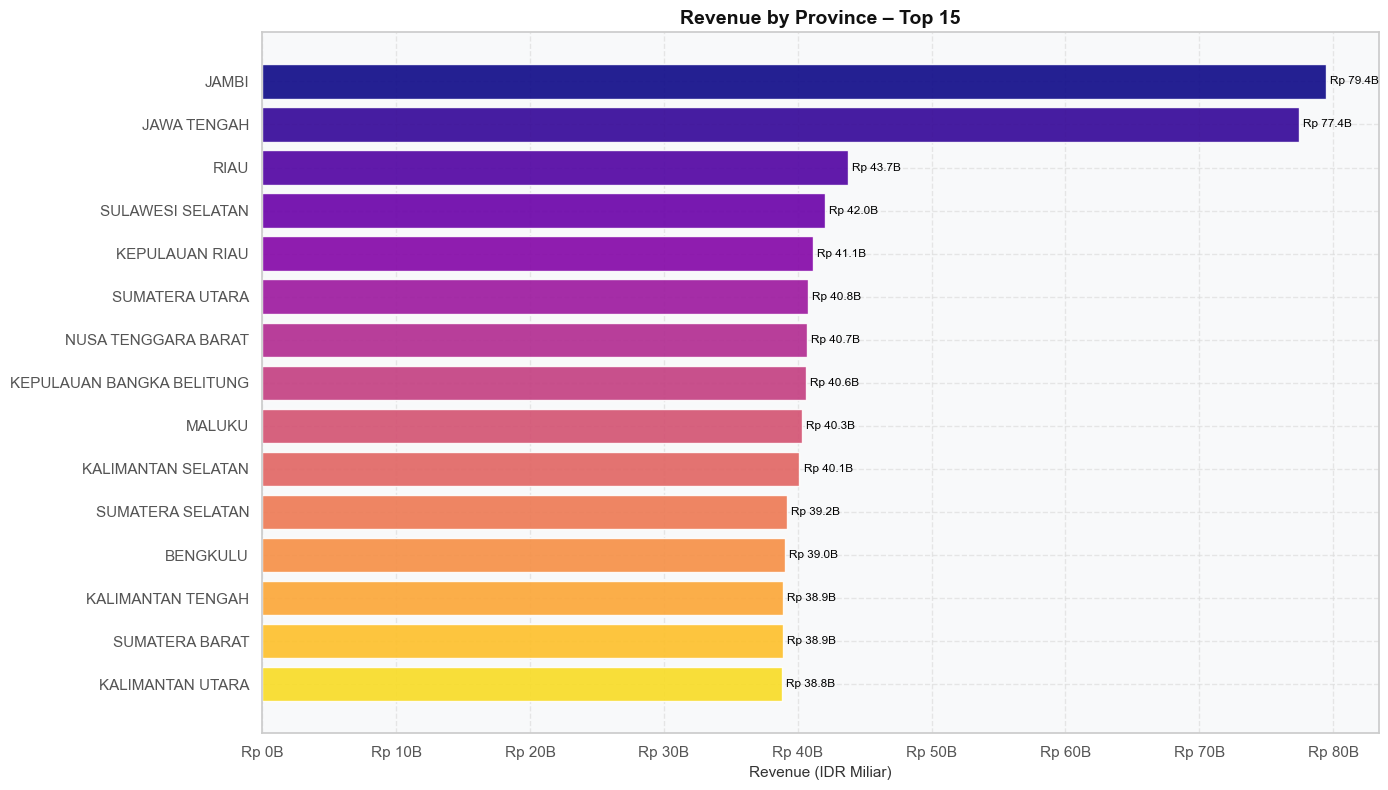

Saved: 04_revenue_by_province.png


In [106]:
rev_prov = (
    df_sell_in.groupby("province_desc")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(14, 8))
colors_prov = [GRADIENT(i / len(rev_prov)) for i in range(len(rev_prov))]
bars = ax.barh(
    rev_prov.index[::-1],
    rev_prov.values[::-1] / 1e9,
    color=colors_prov[::-1],
    alpha=0.9,
)
ax.set_xlabel("Revenue (IDR Miliar)")
ax.set_title("Revenue by Province – Top 15", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}B"))
for bar, val in zip(bars, (rev_prov.values / 1e9)[::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"Rp {val:.1f}B",
        va="center",
        fontsize=8.5,
        color="black",
    )
plt.tight_layout()
save_fig("04_revenue_by_province")


##### 4.3 Revenue berdasarkan Distributor


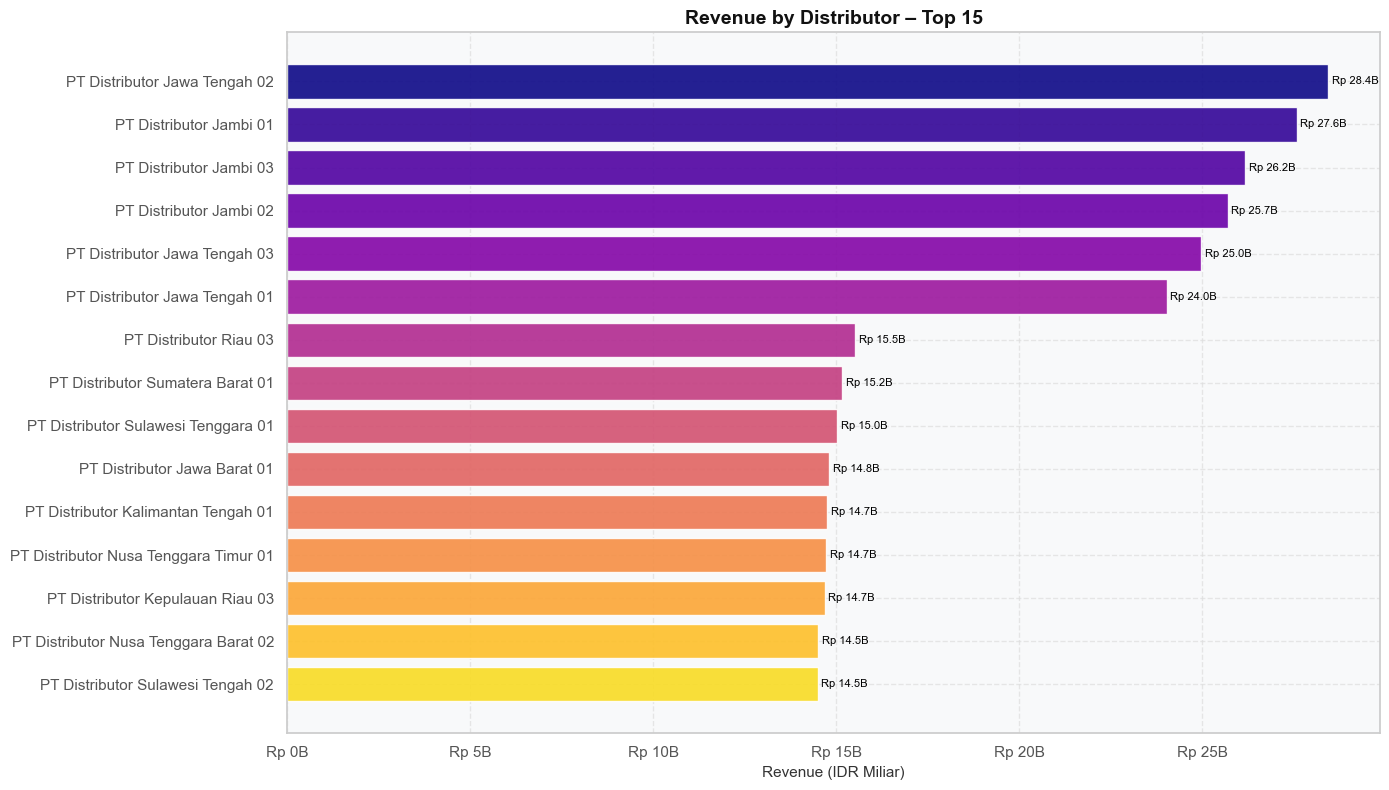

Saved: 05_revenue_by_distributor.png


In [107]:
rev_dist = (
    df_sell_in.groupby("soldto_desc")["revenue"].sum().sort_values(ascending=False).head(15)
)

fig, ax = plt.subplots(figsize=(14, 8))
colors_dist = [GRADIENT(i / len(rev_dist)) for i in range(len(rev_dist))]
bars = ax.barh(
    rev_dist.index[::-1],
    rev_dist.values[::-1] / 1e9,
    color=colors_dist[::-1],
    alpha=0.9,
)
ax.set_xlabel("Revenue (IDR Miliar)")
ax.set_title("Revenue by Distributor – Top 15", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}B"))
for bar, val in zip(bars, (rev_dist.values / 1e9)[::-1]):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"Rp {val:.1f}B",
        va="center",
        fontsize=8,
        color="black",
    )
plt.tight_layout()
save_fig("05_revenue_by_distributor")


##### 4.4 Revenue berdasarkan Brand


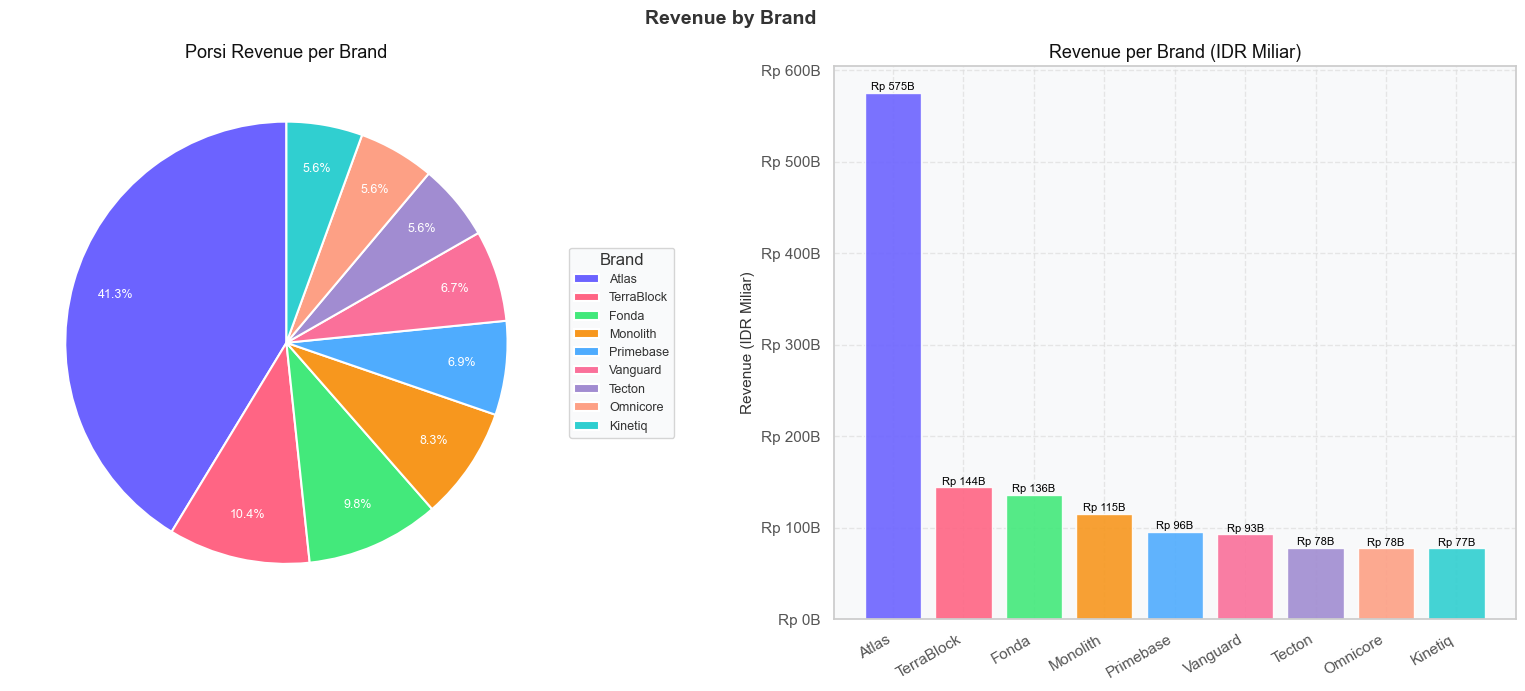

Saved: 06_revenue_by_brand.png


In [108]:
rev_brand = df_sell_in.groupby("brand")["revenue"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Revenue by Brand", fontsize=14, fontweight="bold")

brand_colors = PALETTE[: len(rev_brand)]
wedges, texts, autotexts = axes[0].pie(
    rev_brand.values,
    labels=None,
    autopct="%1.1f%%",
    colors=brand_colors,
    startangle=90,
    pctdistance=0.8,
    wedgeprops=dict(edgecolor="white", lw=1.5),
)
for at in autotexts:
    at.set_color("white")
    at.set_fontsize(9)
axes[0].legend(
    wedges,
    rev_brand.index,
    title="Brand",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=9,
)
axes[0].set_title("Porsi Revenue per Brand")

bars2 = axes[1].bar(
    rev_brand.index, rev_brand.values / 1e9, color=brand_colors, alpha=0.9
)
axes[1].set_ylabel("Revenue (IDR Miliar)")
axes[1].set_title("Revenue per Brand (IDR Miliar)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}B"))
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
for bar, val in zip(bars2, rev_brand.values / 1e9):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"Rp {val:.0f}B",
        ha="center",
        va="bottom",
        fontsize=8,
        color="black",
    )

plt.tight_layout()
save_fig("06_revenue_by_brand")


##### 4.5 Revenue berdasarkan Product (Top 15)


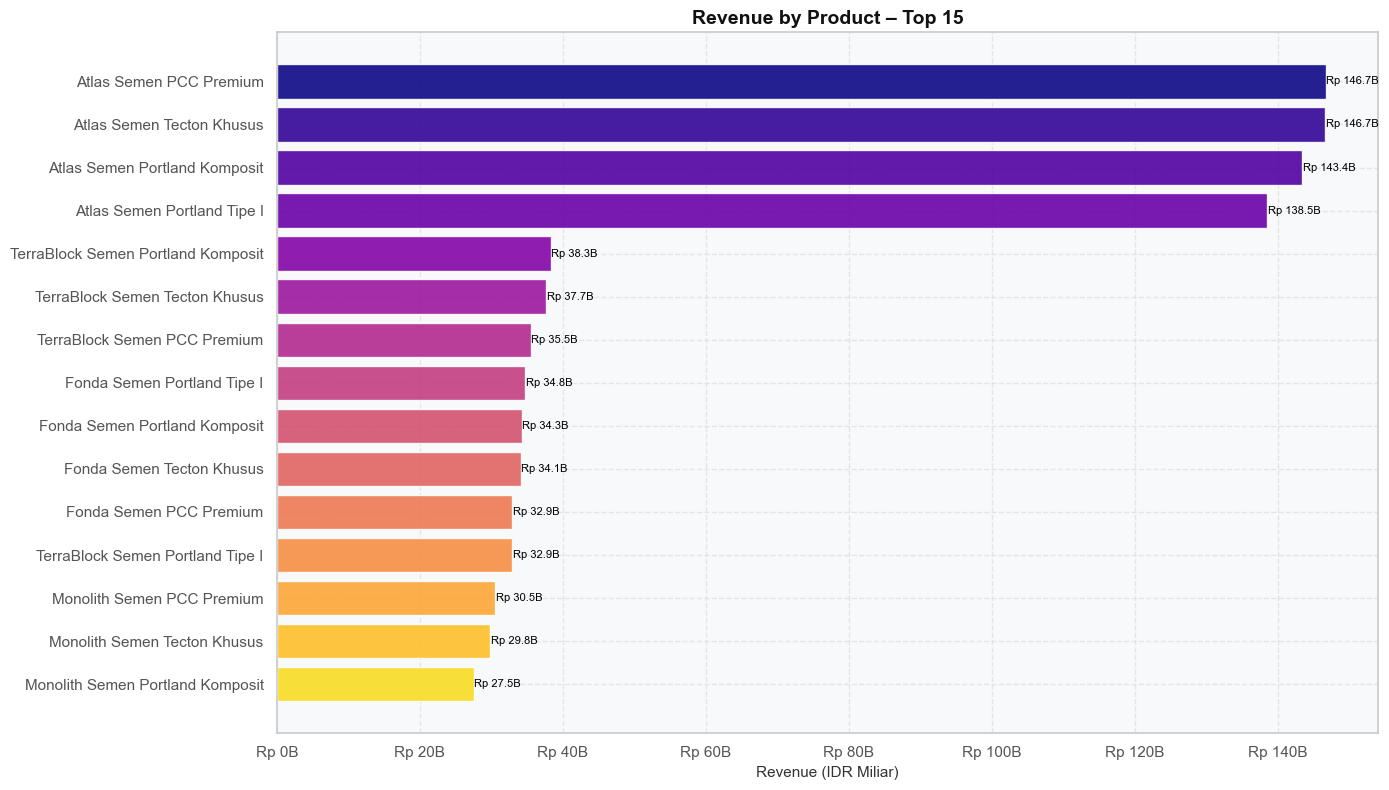

Saved: 07_revenue_by_product.png


In [109]:
rev_prod = (
    df_sell_in.groupby("material_desc")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(14, 8))
colors_prod = [GRADIENT(i / len(rev_prod)) for i in range(len(rev_prod))]
bars = ax.barh(
    rev_prod.index[::-1],
    rev_prod.values[::-1] / 1e9,
    color=colors_prod[::-1],
    alpha=0.9,
)
ax.set_xlabel("Revenue (IDR Miliar)")
ax.set_title("Revenue by Product – Top 15", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}B"))
for bar, val in zip(bars, (rev_prod.values / 1e9)[::-1]):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"Rp {val:.1f}B",
        va="center",
        fontsize=8,
        color="black",
    )
plt.tight_layout()
save_fig("07_revenue_by_product")


##### 4.6 Analisis Pareto


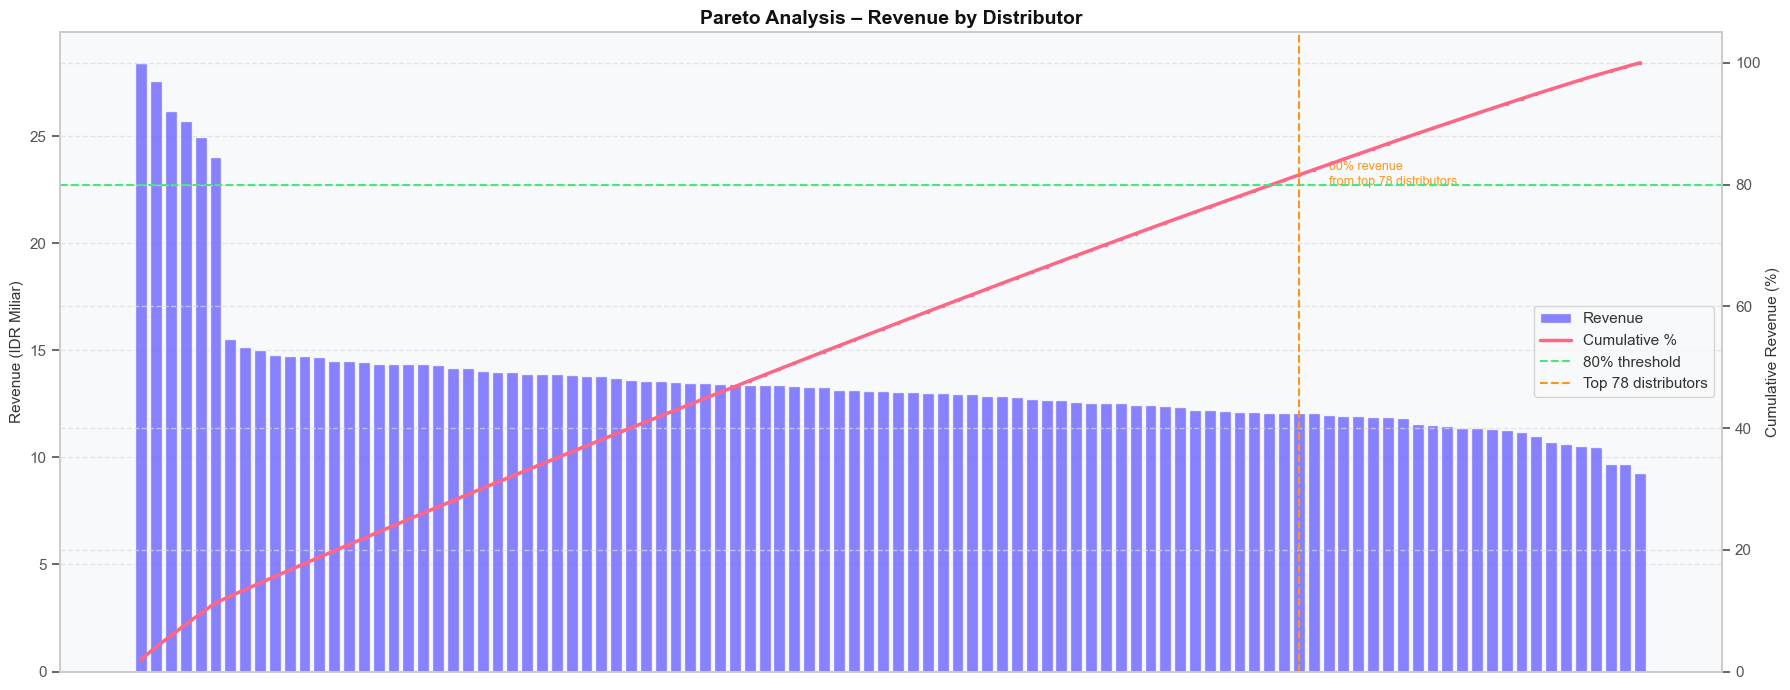

Saved: 08_pareto_distributor.png

  PARETO INSIGHT: Top 78 distributors = 80% of total revenue
  Total Revenue: Rp 1.4T
  Best Month Revenue: Rp 120.9B  (2026-08)


In [110]:
rev_dist_all = (
    df_sell_in.groupby("soldto_desc")["revenue"].sum().sort_values(ascending=False)
)
cum_pct = rev_dist_all.cumsum() / rev_dist_all.sum() * 100
n_80pct = (cum_pct < 80).sum() + 1

fig, ax1 = plt.subplots(figsize=(18, 7))
ax1.bar(
    range(len(rev_dist_all)),
    rev_dist_all.values / 1e9,
    color="#6c63ff",
    alpha=0.8,
    label="Revenue",
)
ax1.set_ylabel("Revenue (IDR Miliar)")
ax1.set_title(
    "Pareto Analysis – Revenue by Distributor", fontsize=14, fontweight="bold"
)
ax1.set_xticks([])

ax2 = ax1.twinx()
ax2.plot(
    range(len(cum_pct)),
    cum_pct.values,
    color="#ff6584",
    lw=2.5,
    marker=".",
    ms=3,
    label="Cumulative %",
)
ax2.axhline(80, color="#43e97b", lw=1.5, ls="--", label="80% threshold")
ax2.axvline(
    n_80pct, color="#f7971e", lw=1.5, ls="--", label=f"Top {n_80pct} distributors"
)
ax2.set_ylabel("Cumulative Revenue (%)")
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
ax1.text(
    n_80pct + 2,
    rev_dist_all.values.max() / 1e9 * 0.8,
    f"80% revenue\nfrom top {n_80pct} distributors",
    color="#f7971e",
    fontsize=9,
)
plt.tight_layout()
save_fig("08_pareto_distributor")

print(f"\n  PARETO INSIGHT: Top {n_80pct} distributors = 80% of total revenue")
print(f"  Total Revenue: {fmt_idr(df_sell_in['revenue'].sum())}")
print(
    f"  Best Month Revenue: {fmt_idr(rev_monthly['revenue'].max())}  ({rev_monthly.loc[rev_monthly['revenue'].idxmax(),'year_month']})"
)


#### Bagian 5 – Analisis Sell-in vs Sell-out

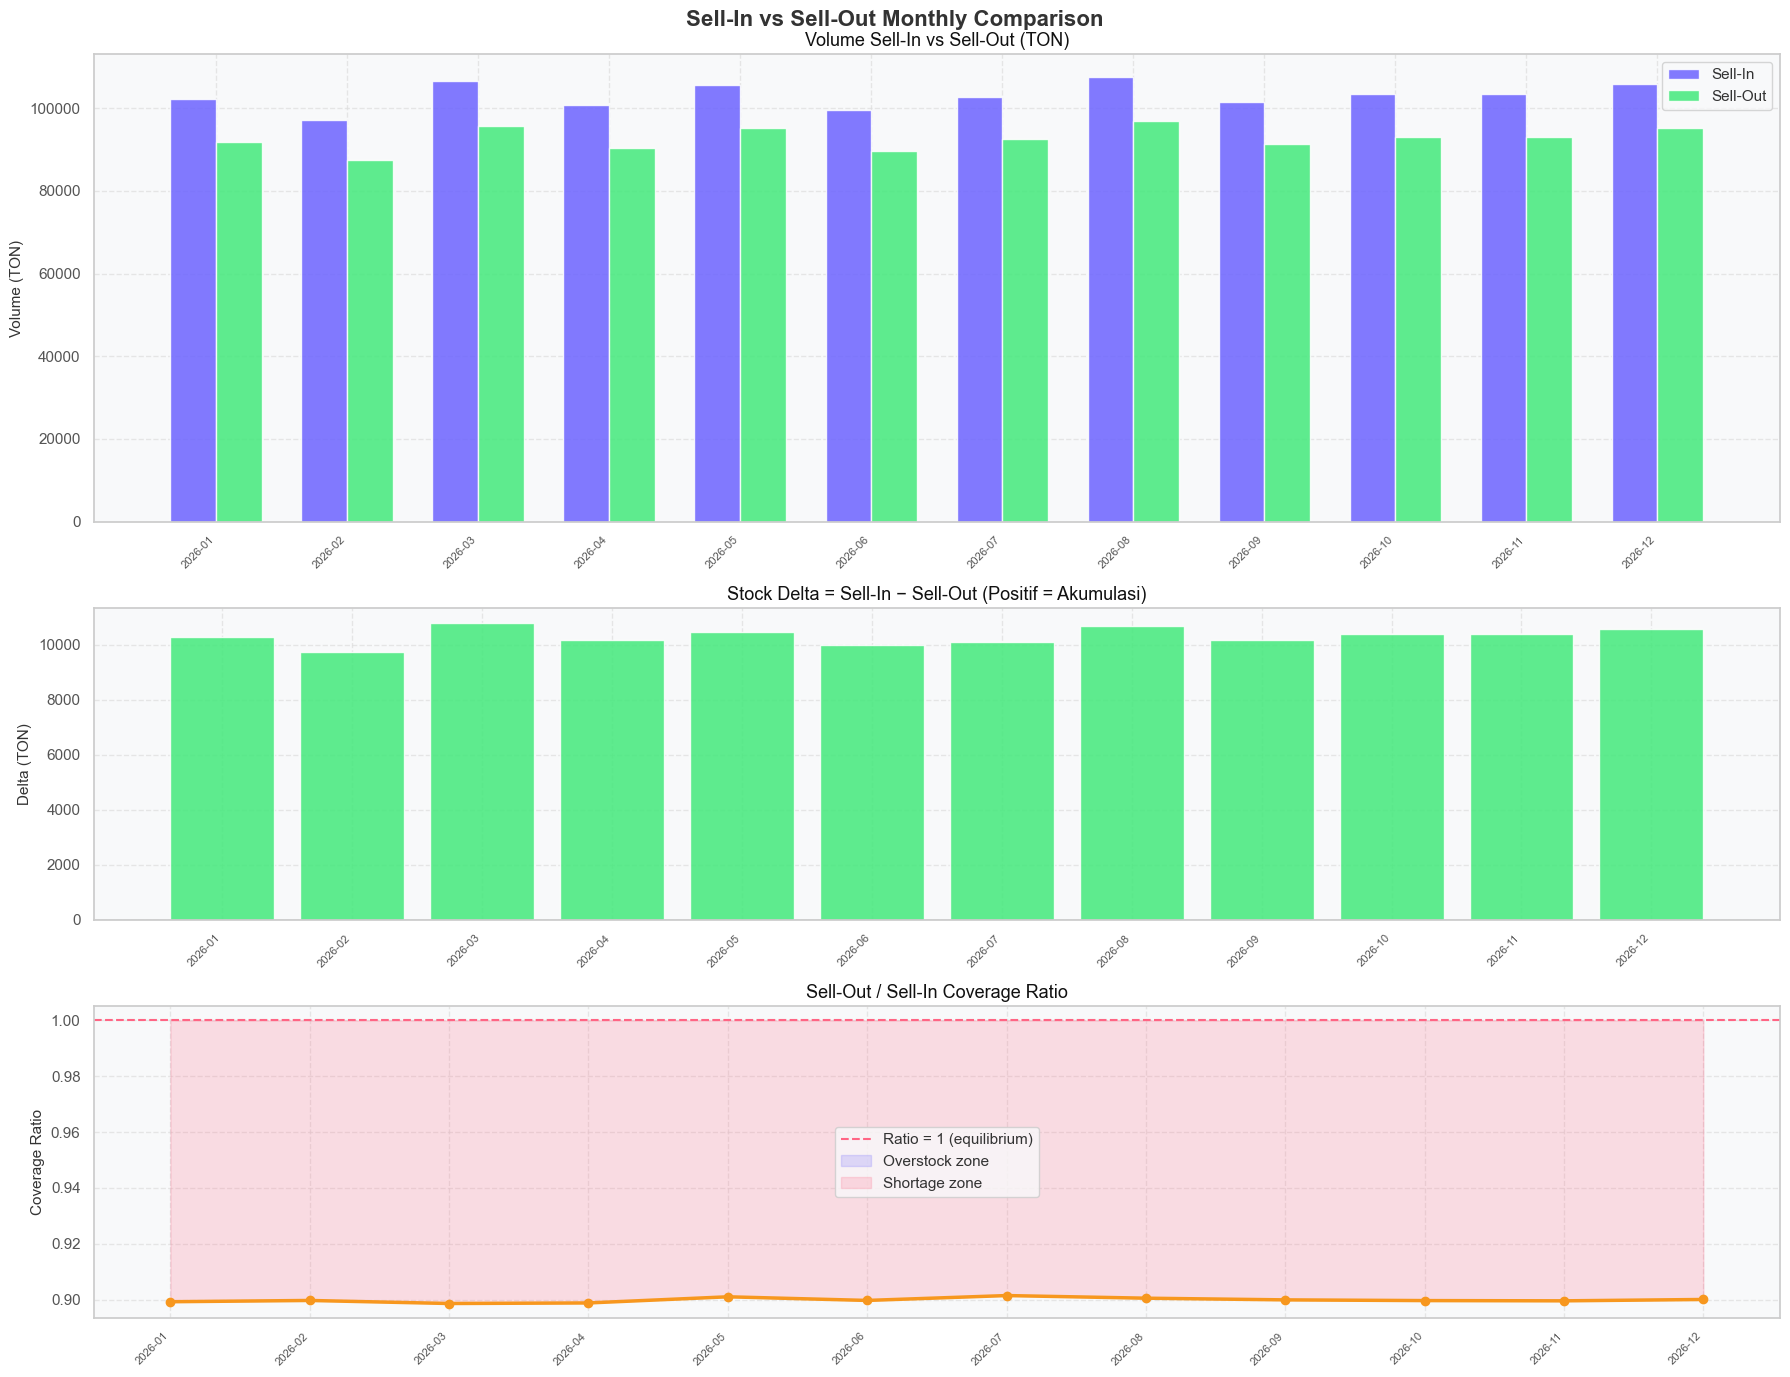

Saved: 09_sellin_vs_sellout.png

  Total Sell-In  :  1,236,695.7 TON
  Total Sell-Out :  1,112,887.6 TON
  Stock Delta    :    123,808.1 TON
  Overall Coverage Ratio: 0.900


In [111]:
si_monthly = (
    df_sell_in.groupby("year_month")["quantity"]
    .sum()
    .reset_index()
    .rename(columns={"quantity": "sell_in"})
)
so_monthly = (
    df_sell_out.groupby("year_month")["sum(tonase)"]
    .sum()
    .reset_index()
    .rename(columns={"sum(tonase)": "sell_out"})
)
si_so = si_monthly.merge(so_monthly, on="year_month", how="outer").sort_values(
    "year_month"
)
si_so["stock_delta"] = si_so["sell_in"] - si_so["sell_out"]
si_so["coverage_ratio"] = si_so["sell_out"] / si_so["sell_in"]

fig, axes = plt.subplots(
    3, 1, figsize=(18, 14), gridspec_kw={"height_ratios": [3, 2, 2]}
)
fig.suptitle(
    "Sell-In vs Sell-Out Monthly Comparison", fontsize=16, fontweight="bold"
)

# Volume comparison
x = np.arange(len(si_so))
w = 0.35
axes[0].bar(
    x - w / 2, si_so["sell_in"], w, label="Sell-In", color="#6c63ff", alpha=0.85
)
axes[0].bar(
    x + w / 2, si_so["sell_out"], w, label="Sell-Out", color="#43e97b", alpha=0.85
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(si_so["year_month"], rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Volume (TON)")
axes[0].set_title("Volume Sell-In vs Sell-Out (TON)")
axes[0].legend()

# Stock delta
delta_colors = [
    "#43e97b" if v >= 0 else "#ff6584" for v in si_so["stock_delta"].fillna(0)
]
axes[1].bar(
    si_so["year_month"], si_so["stock_delta"].fillna(0), color=delta_colors, alpha=0.85
)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Delta (TON)")
axes[1].set_title("Stock Delta = Sell-In − Sell-Out (Positif = Akumulasi)")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=8)

# Coverage ratio
axes[2].plot(
    si_so["year_month"], si_so["coverage_ratio"], color="#f7971e", marker="o", lw=2.5
)
axes[2].axhline(1, color="#ff6584", lw=1.5, ls="--", label="Ratio = 1 (equilibrium)")
axes[2].fill_between(
    si_so["year_month"],
    si_so["coverage_ratio"],
    1,
    where=(si_so["coverage_ratio"] > 1),
    alpha=0.2,
    color="#6c63ff",
    label="Overstock zone",
)
axes[2].fill_between(
    si_so["year_month"],
    si_so["coverage_ratio"],
    1,
    where=(si_so["coverage_ratio"] < 1),
    alpha=0.2,
    color="#ff6584",
    label="Shortage zone",
)
axes[2].set_ylabel("Coverage Ratio")
axes[2].set_title("Sell-Out / Sell-In Coverage Ratio")
axes[2].legend()
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
save_fig("09_sellin_vs_sellout")

# Stats
total_si = df_sell_in["quantity"].sum()
total_so = df_sell_out["sum(tonase)"].sum()
print(f"\n  Total Sell-In  : {total_si:>12,.1f} TON")
print(f"  Total Sell-Out : {total_so:>12,.1f} TON")
print(f"  Stock Delta    : {total_si - total_so:>12,.1f} TON")
print(f"  Overall Coverage Ratio: {total_so/total_si:.3f}")


#### Bagian 6 – Analisis Produk


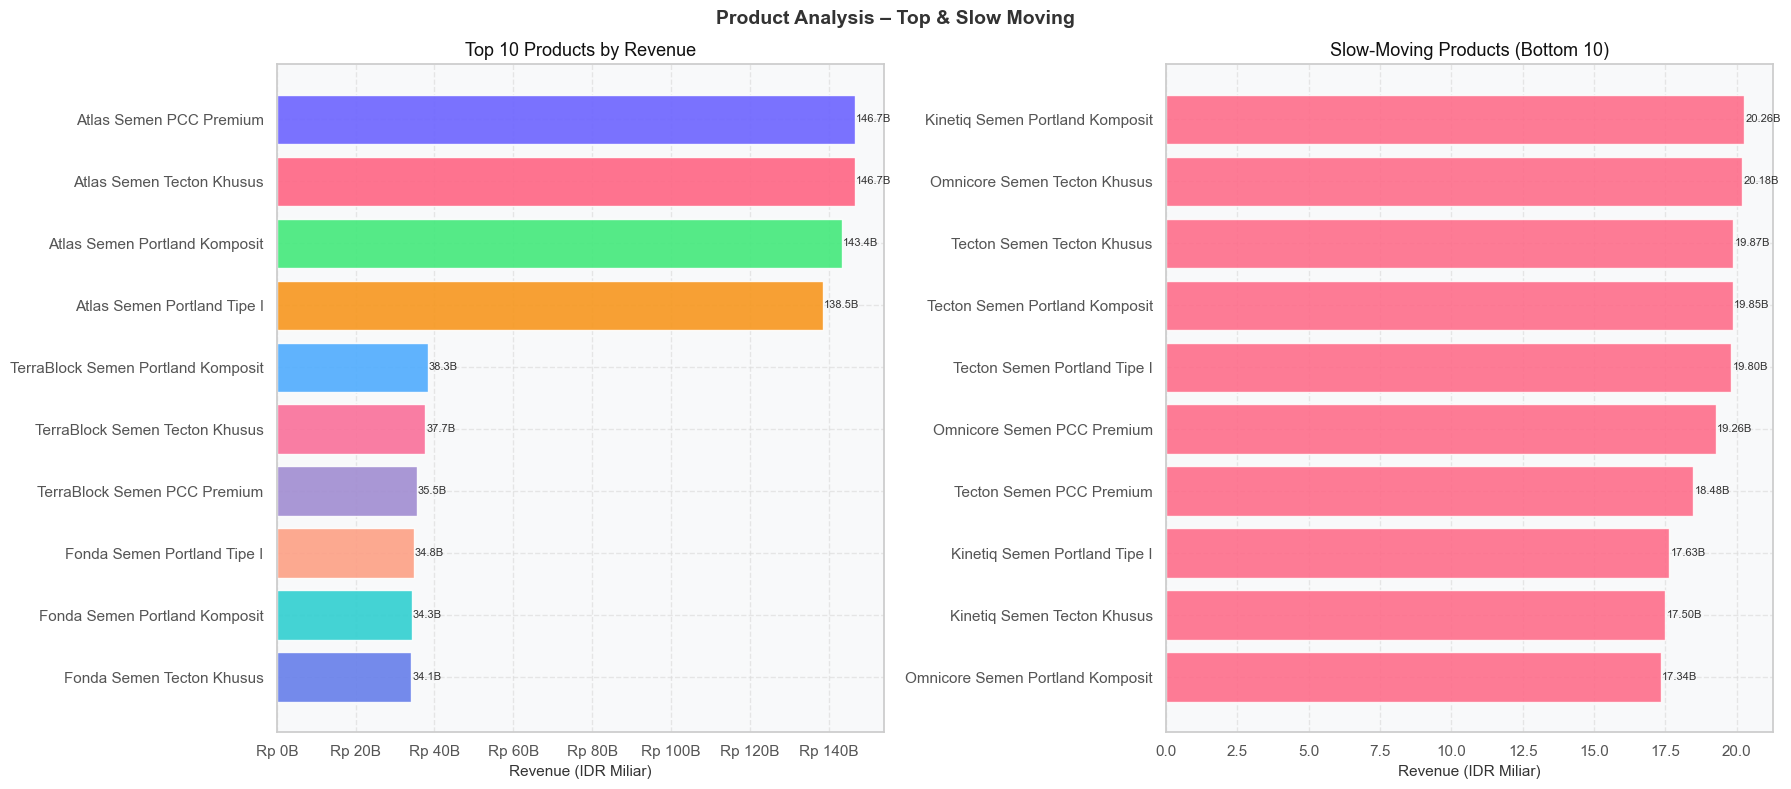

Saved: 10_product_analysis.png


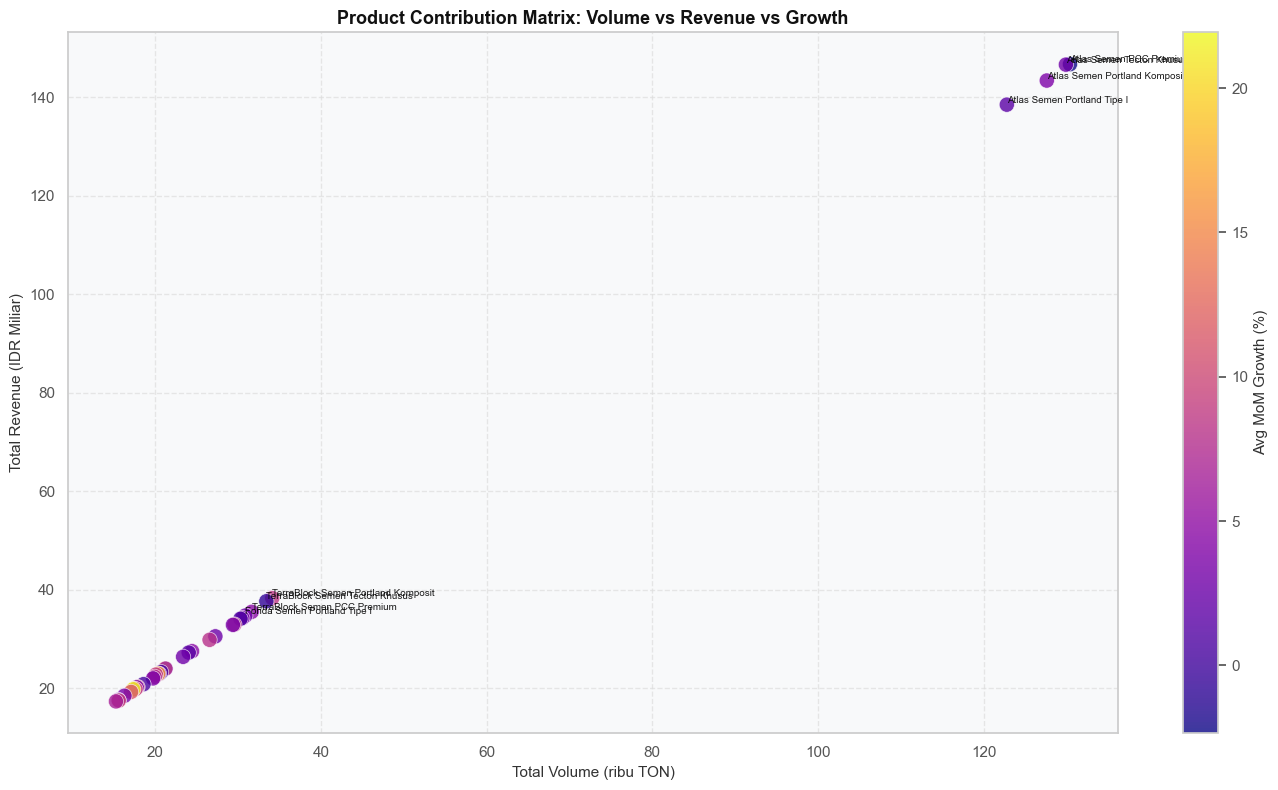

Saved: 11_product_contribution_matrix.png

  TOP 5 Products by Revenue:
                        material_desc  total_revenue  total_qty  \
0             Atlas Semen PCC Premium   146744668247  130389.46   
1           Atlas Semen Tecton Khusus   146654386152  129898.87   
2       Atlas Semen Portland Komposit   143422363007  127594.25   
3         Atlas Semen Portland Tipe I   138526422765  122771.13   
4  TerraBlock Semen Portland Komposit    38306676850   34137.04   

   revenue_share  avg_mom_growth  
0      10.537011       -2.348118  
1      10.530528        2.778276  
2      10.298453        3.735243  
3       9.946899        1.594799  
4       2.750614        8.499125  


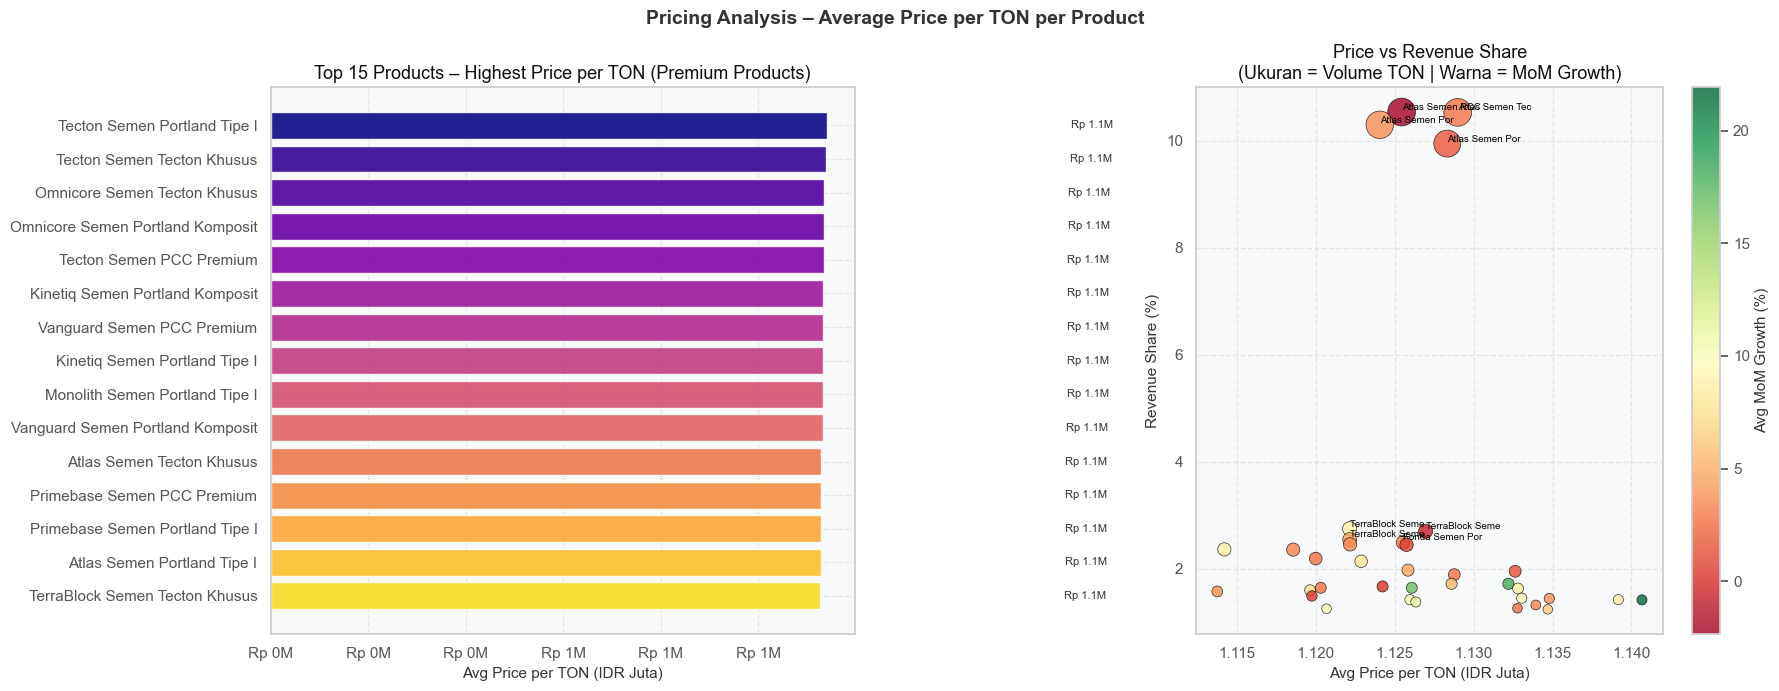

Saved: 11b_product_pricing_analysis.png

  Product Pricing Summary (Top 10 by Price per TON):
                     material_desc  price_per_ton  total_revenue  revenue_share
           Atlas Semen PCC Premium   1.125434e+06   146744668247      10.537011
         Atlas Semen Tecton Khusus   1.128989e+06   146654386152      10.530528
     Atlas Semen Portland Komposit   1.124050e+06   143422363007      10.298453
       Atlas Semen Portland Tipe I   1.128331e+06   138526422765       9.946899
TerraBlock Semen Portland Komposit   1.122144e+06    38306676850       2.750614
    TerraBlock Semen Tecton Khusus   1.126955e+06    37668259886       2.704772
      TerraBlock Semen PCC Premium   1.122138e+06    35524192209       2.550817
       Fonda Semen Portland Tipe I   1.125525e+06    34765732309       2.496356
     Fonda Semen Portland Komposit   1.122169e+06    34256652131       2.459801
         Fonda Semen Tecton Khusus   1.125748e+06    34118592506       2.449888


In [112]:
prod_agg = (
    df_sell_in.groupby("material_desc")
    .agg(
        total_revenue=("revenue", "sum"),
        total_qty=("quantity", "sum"),
        avg_price=("revenue", "mean"),
        n_txn=("revenue", "count"),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)
prod_agg["revenue_share"] = (
    prod_agg["total_revenue"] / prod_agg["total_revenue"].sum() * 100
)
prod_agg["cum_share"] = prod_agg["revenue_share"].cumsum()

# Monthly product revenue - Perbaikan di baris ini (menggunakan df_sell_in)
prod_monthly = (
    df_sell_in.groupby(["year_month", "material_desc"])["revenue"].sum().reset_index()
)
prod_growth = (
    prod_monthly.groupby("material_desc")
    .apply(lambda g: g.sort_values("year_month")["revenue"].pct_change().mean() * 100)
    .reset_index(name="avg_mom_growth")
)

prod_agg = prod_agg.merge(prod_growth, on="material_desc", how="left")

# Top 10 products
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Product Analysis – Top & Slow Moving", fontsize=14, fontweight="bold")

top10 = prod_agg.head(10)
colors_t = PALETTE[:10]
bars = axes[0].barh(
    top10["material_desc"][::-1],
    top10["total_revenue"][::-1] / 1e9,
    color=colors_t[::-1],
    alpha=0.9,
)
axes[0].set_xlabel("Revenue (IDR Miliar)")
axes[0].set_title("Top 10 Products by Revenue")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}B"))
for bar, val in zip(bars, (top10["total_revenue"].values / 1e9)[::-1]):
    axes[0].text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}B",
        va="center",
        fontsize=8,
    )

slow10 = prod_agg.tail(10).sort_values("total_revenue")
bars2 = axes[1].barh(
    slow10["material_desc"], slow10["total_revenue"] / 1e9, color="#ff6584", alpha=0.85
)
axes[1].set_xlabel("Revenue (IDR Miliar)")
axes[1].set_title("Slow-Moving Products (Bottom 10)")
for bar, val in zip(bars2, slow10["total_revenue"].values / 1e9):
    axes[1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}B",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
save_fig("10_product_analysis")

# Product contribution scatter
fig, ax = plt.subplots(figsize=(14, 8))
sc = ax.scatter(
    prod_agg["total_qty"] / 1e3,
    prod_agg["total_revenue"] / 1e9,
    c=prod_agg["avg_mom_growth"],
    cmap="plasma",
    s=120,
    alpha=0.8,
    edgecolors="white",
    lw=0.5,
)
plt.colorbar(sc, ax=ax, label="Avg MoM Growth (%)")
ax.set_xlabel("Total Volume (ribu TON)")
ax.set_ylabel("Total Revenue (IDR Miliar)")
ax.set_title(
    "Product Contribution Matrix: Volume vs Revenue vs Growth",
    fontsize=13,
    fontweight="bold",
)
for _, row in prod_agg.head(8).iterrows():
    ax.annotate(
        row["material_desc"],
        (row["total_qty"] / 1e3, row["total_revenue"] / 1e9),
        fontsize=7,
        ha="left",
        va="bottom",
        color="black",
        alpha=0.9,
    )
plt.tight_layout()
save_fig("11_product_contribution_matrix")

print("\n  TOP 5 Products by Revenue:")
print(
    prod_agg[
        [
            "material_desc",
            "total_revenue",
            "total_qty",
            "revenue_share",
            "avg_mom_growth",
        ]
    ].head()
)

# ── Price per TON per Product ─────────────────────────────────────────────────
# Actual avg price per ton = total_revenue / total_qty
prod_agg["price_per_ton"] = prod_agg["total_revenue"] / prod_agg["total_qty"].replace(0, float("nan"))

# Top 15 products by price per ton (premium positioning analysis)
price_top = prod_agg.dropna(subset=["price_per_ton"]).sort_values("price_per_ton", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Pricing Analysis – Average Price per TON per Product", fontsize=14, fontweight="bold")

# Left: Price per ton ranking
price_colors = [GRADIENT(i / len(price_top)) for i in range(len(price_top))]
bars_p = axes[0].barh(
    price_top["material_desc"][::-1],
    price_top["price_per_ton"][::-1] / 1e6,
    color=price_colors[::-1],
    alpha=0.9,
)
axes[0].set_xlabel("Avg Price per TON (IDR Juta)")
axes[0].set_title("Top 15 Products – Highest Price per TON (Premium Products)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}M"))
for bar, val in zip(bars_p, (price_top["price_per_ton"].values / 1e6)[::-1]):
    axes[0].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"Rp {val:.1f}M",
        va="center",
        fontsize=8,
    )

# Right: Revenue share vs Price per ton scatter (size = volume)
sc_p = axes[1].scatter(
    prod_agg["price_per_ton"] / 1e6,
    prod_agg["revenue_share"],
    s=prod_agg["total_qty"] / prod_agg["total_qty"].max() * 400,
    c=prod_agg["avg_mom_growth"].fillna(0),
    cmap="RdYlGn",
    alpha=0.8,
    edgecolors="black",
    lw=0.5,
)
plt.colorbar(sc_p, ax=axes[1], label="Avg MoM Growth (%)")
axes[1].set_xlabel("Avg Price per TON (IDR Juta)")
axes[1].set_ylabel("Revenue Share (%)")
axes[1].set_title("Price vs Revenue Share\n(Ukuran = Volume TON | Warna = MoM Growth)")
for _, row in prod_agg.head(8).iterrows():
    axes[1].annotate(
        row["material_desc"][:15],
        (row["price_per_ton"] / 1e6, row["revenue_share"]),
        fontsize=7,
        ha="left",
        va="bottom",
        color="black",
    )

plt.tight_layout()
save_fig("11b_product_pricing_analysis")

print("\n  Product Pricing Summary (Top 10 by Price per TON):")
print(prod_agg[["material_desc", "price_per_ton", "total_revenue", "revenue_share"]].head(10).to_string(index=False))


#### Bagian 7 – Analisis Distributor


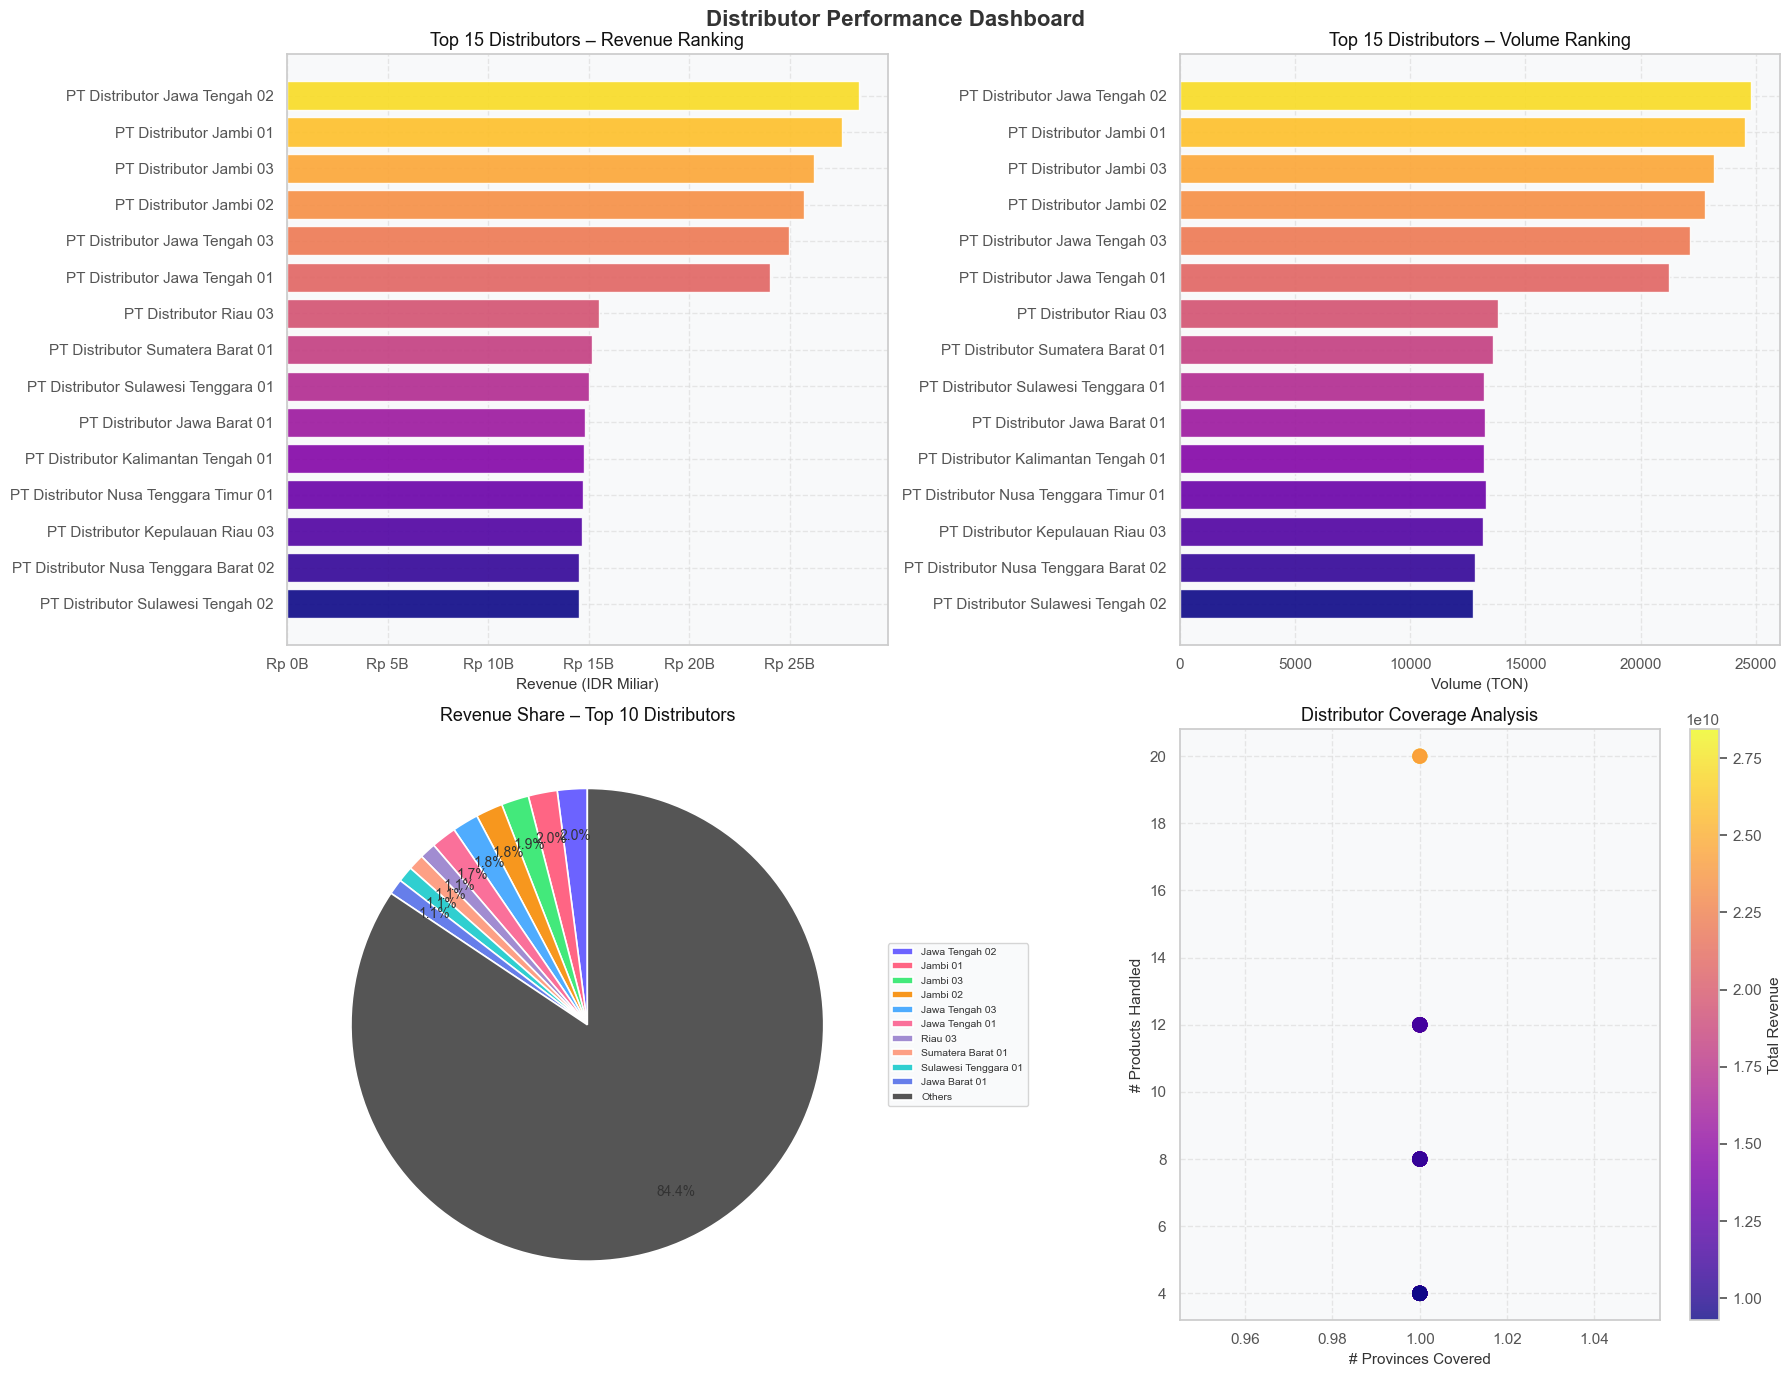

Saved: 12_distributor_analysis.png

  Total Distributors: 102
  Top 1 Distributor:  PT Distributor Jawa Tengah 02  (2.0%)
  Top 10 Distributors: 15.6% of total revenue


In [113]:
dist_agg = (
    df_sell_in.groupby("soldto_desc")
    .agg(
        total_revenue=("revenue", "sum"),
        total_qty=("quantity", "sum"),
        n_txn=("revenue", "count"),
        n_products=("material_desc", "nunique"),
        n_provinces=("province_desc", "nunique"),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)
dist_agg["revenue_rank"] = range(1, len(dist_agg) + 1)
dist_agg["revenue_share"] = (
    dist_agg["total_revenue"] / dist_agg["total_revenue"].sum() * 100
)
dist_agg["cum_share"] = dist_agg["revenue_share"].cumsum()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Distributor Performance Dashboard", fontsize=16, fontweight="bold")

# Revenue ranking
top15_d = dist_agg.head(15)
axes[0, 0].barh(
    top15_d["soldto_desc"][::-1],
    top15_d["total_revenue"][::-1] / 1e9,
    color=[GRADIENT(i / 15) for i in range(15)],
    alpha=0.9,
)
axes[0, 0].set_xlabel("Revenue (IDR Miliar)")
axes[0, 0].set_title("Top 15 Distributors – Revenue Ranking")
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}B"))

# Volume ranking
axes[0, 1].barh(
    top15_d["soldto_desc"][::-1],
    top15_d["total_qty"][::-1],
    color=[GRADIENT(i / 15) for i in range(15)],
    alpha=0.9,
)
axes[0, 1].set_xlabel("Volume (TON)")
axes[0, 1].set_title("Top 15 Distributors – Volume Ranking")

# Revenue share pie (top 10 vs others)
top10_d = dist_agg.head(10)
others = dist_agg.iloc[10:]["total_revenue"].sum()
labels = list(
    top10_d["soldto_desc"].str.replace("PT Distributor ", "", regex=False)
) + ["Others"]
sizes = list(top10_d["total_revenue"].values) + [others]
axes[1, 0].pie(
    sizes,
    labels=None,
    autopct="%1.1f%%",
    colors=PALETTE + ["#555555"],
    pctdistance=0.8,
    startangle=90,
    wedgeprops=dict(edgecolor="white", lw=1.2),
)
axes[1, 0].set_title("Revenue Share – Top 10 Distributors")
axes[1, 0].legend(labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=7.5)

# Coverage (n_provinces vs n_products scatter)
sc = axes[1, 1].scatter(
    dist_agg["n_provinces"],
    dist_agg["n_products"],
    c=dist_agg["total_revenue"],
    cmap="plasma",
    s=100,
    alpha=0.8,
)
plt.colorbar(sc, ax=axes[1, 1], label="Total Revenue")
axes[1, 1].set_xlabel("# Provinces Covered")
axes[1, 1].set_ylabel("# Products Handled")
axes[1, 1].set_title("Distributor Coverage Analysis")

plt.tight_layout()
save_fig("12_distributor_analysis")

print(f"\n  Total Distributors: {dist_agg.shape[0]}")
print(
    f"  Top 1 Distributor:  {dist_agg.iloc[0]['soldto_desc']}  ({dist_agg.iloc[0]['revenue_share']:.1f}%)"
)
print(
    f"  Top 10 Distributors: {dist_agg.head(10)['revenue_share'].sum():.1f}% of total revenue"
)


#### Bagian 8 – Analisis Toko


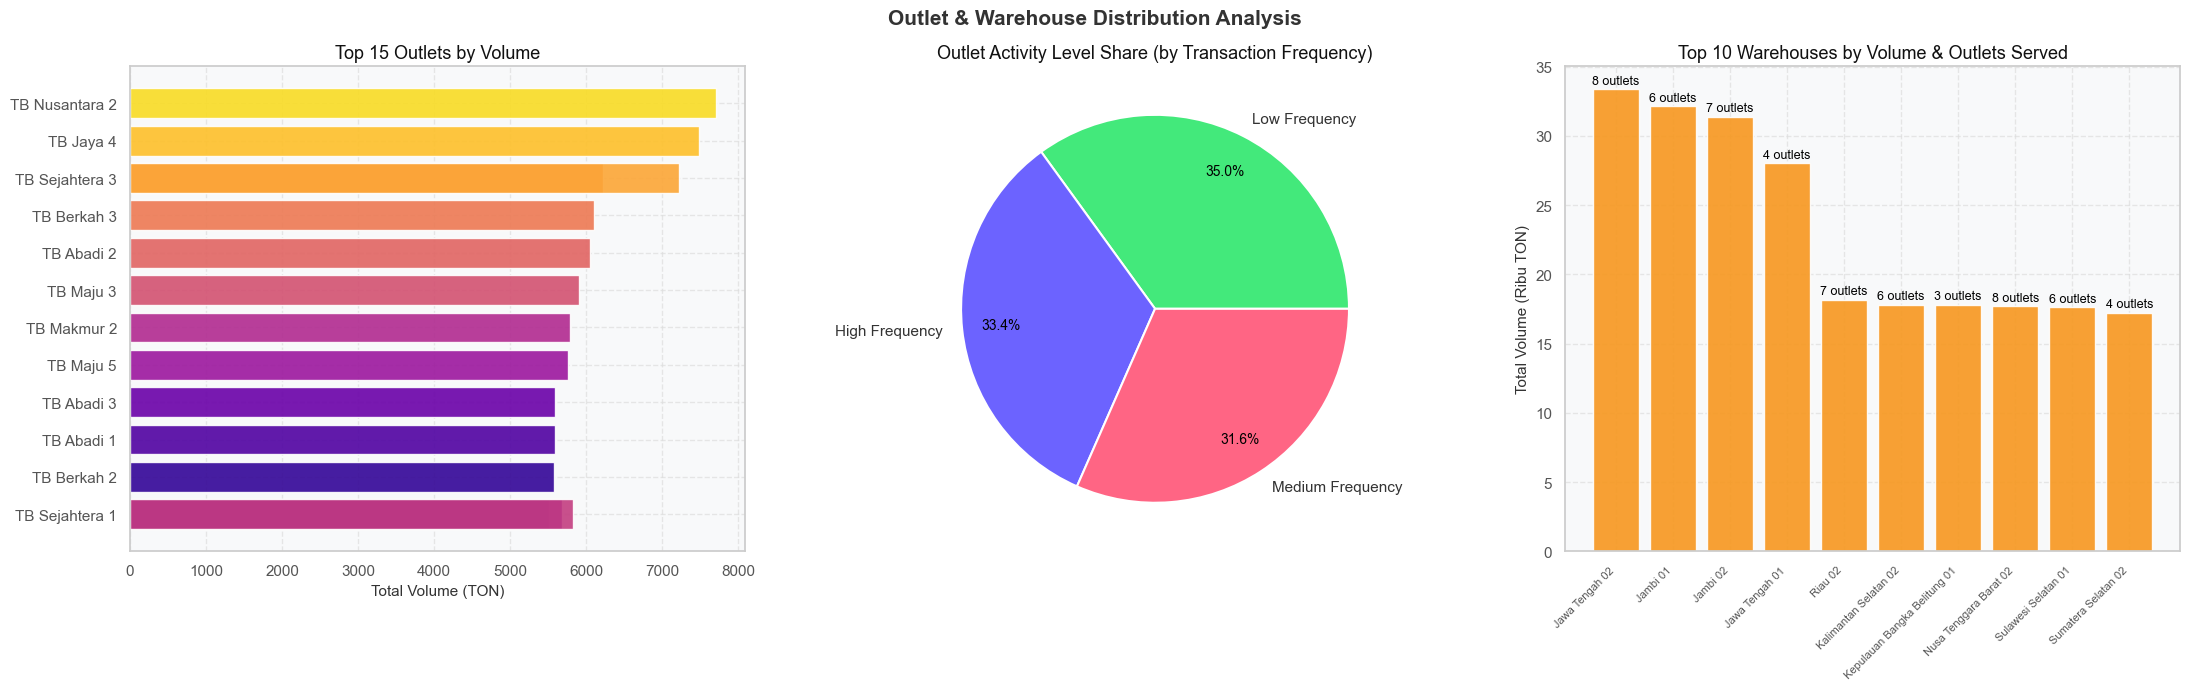

Saved: 13_outlet_analysis.png

  Total Unique Outlets: 383

  Outlet Activity Level Distribution:
activity_level
Low Frequency       134
High Frequency      128
Medium Frequency    121

  Top 5 Warehouses by Volume:
          nama_gudang  total_volume  unique_outlets
Gudang Jawa Tengah 02      33355.46               8
      Gudang Jambi 01      32133.37               6
      Gudang Jambi 02      31346.20               7
Gudang Jawa Tengah 01      28006.23               4
       Gudang Riau 02      18166.25               7


In [114]:
outlet_agg = (
    df_sell_out.groupby(["kode_toko", "nama_toko", "kode_gudang", "nama_gudang"])
    .agg(
        total_volume=("sum(tonase)", "sum"),
        n_txn=("sum(tonase)", "count"),
        avg_volume=("sum(tonase)", "mean"),
        provinsi=("provinsi", "first"),
    )
    .reset_index()
    .sort_values("total_volume", ascending=False)
)

outlet_agg["activity_level"] = pd.qcut(
    outlet_agg["n_txn"],
    q=3,
    labels=["Low Frequency", "Medium Frequency", "High Frequency"]
)

wh_agg = (
    df_sell_out.groupby(["kode_gudang", "nama_gudang"])
    .agg(
        total_volume=("sum(tonase)", "sum"),
        unique_outlets=("kode_toko", "nunique"),
        n_txn=("sum(tonase)", "count")
    )
    .reset_index()
    .sort_values("total_volume", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Outlet & Warehouse Distribution Analysis", fontsize=15, fontweight="bold")

# 1. Top 15 Outlets by Volume
top15_o = outlet_agg.head(15)
axes[0].barh(
    top15_o["nama_toko"][::-1],
    top15_o["total_volume"][::-1],
    color=[GRADIENT(i / 15) for i in range(15)],
    alpha=0.9,
)
axes[0].set_xlabel("Total Volume (TON)")
axes[0].set_title("Top 15 Outlets by Volume")

# 2. Activity Level Share (Keaktifan)
activity_cnt = outlet_agg["activity_level"].value_counts()
activity_colors = ["#43e97b", "#6c63ff", "#ff6584"]
wedges, _, autotexts = axes[1].pie(
    activity_cnt.values,
    labels=activity_cnt.index,
    autopct="%1.1f%%",
    colors=activity_colors,
    pctdistance=0.8,
    wedgeprops=dict(edgecolor="white", lw=1.5),
)
for at in autotexts:
    at.set_color("black")
    at.set_fontsize(10)
axes[1].set_title("Outlet Activity Level Share (by Transaction Frequency)")

# 3. Top 10 Warehouses by Volume & Outlets Served
top10_wh = wh_agg.head(10)
wh_bars = axes[2].bar(
    top10_wh["nama_gudang"].str.replace("Gudang ", ""),
    top10_wh["total_volume"] / 1e3,
    color="#f7971e",
    alpha=0.9
)
axes[2].set_ylabel("Total Volume (Ribu TON)")
axes[2].set_title("Top 10 Warehouses by Volume & Outlets Served")
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right", fontsize=8)

for bar, outlets in zip(wh_bars, top10_wh["unique_outlets"]):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{outlets} outlets",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black"
    )

plt.tight_layout()
save_fig("13_outlet_analysis")

print(f"\n  Total Unique Outlets: {outlet_agg.shape[0]:,}")
print("\n  Outlet Activity Level Distribution:")
print(outlet_agg["activity_level"].value_counts().to_string())
print("\n  Top 5 Warehouses by Volume:")
print(top10_wh[["nama_gudang", "total_volume", "unique_outlets"]].head().to_string(index=False))

#### Bagian 9 – Analisis Optimisasi Penyimpanan


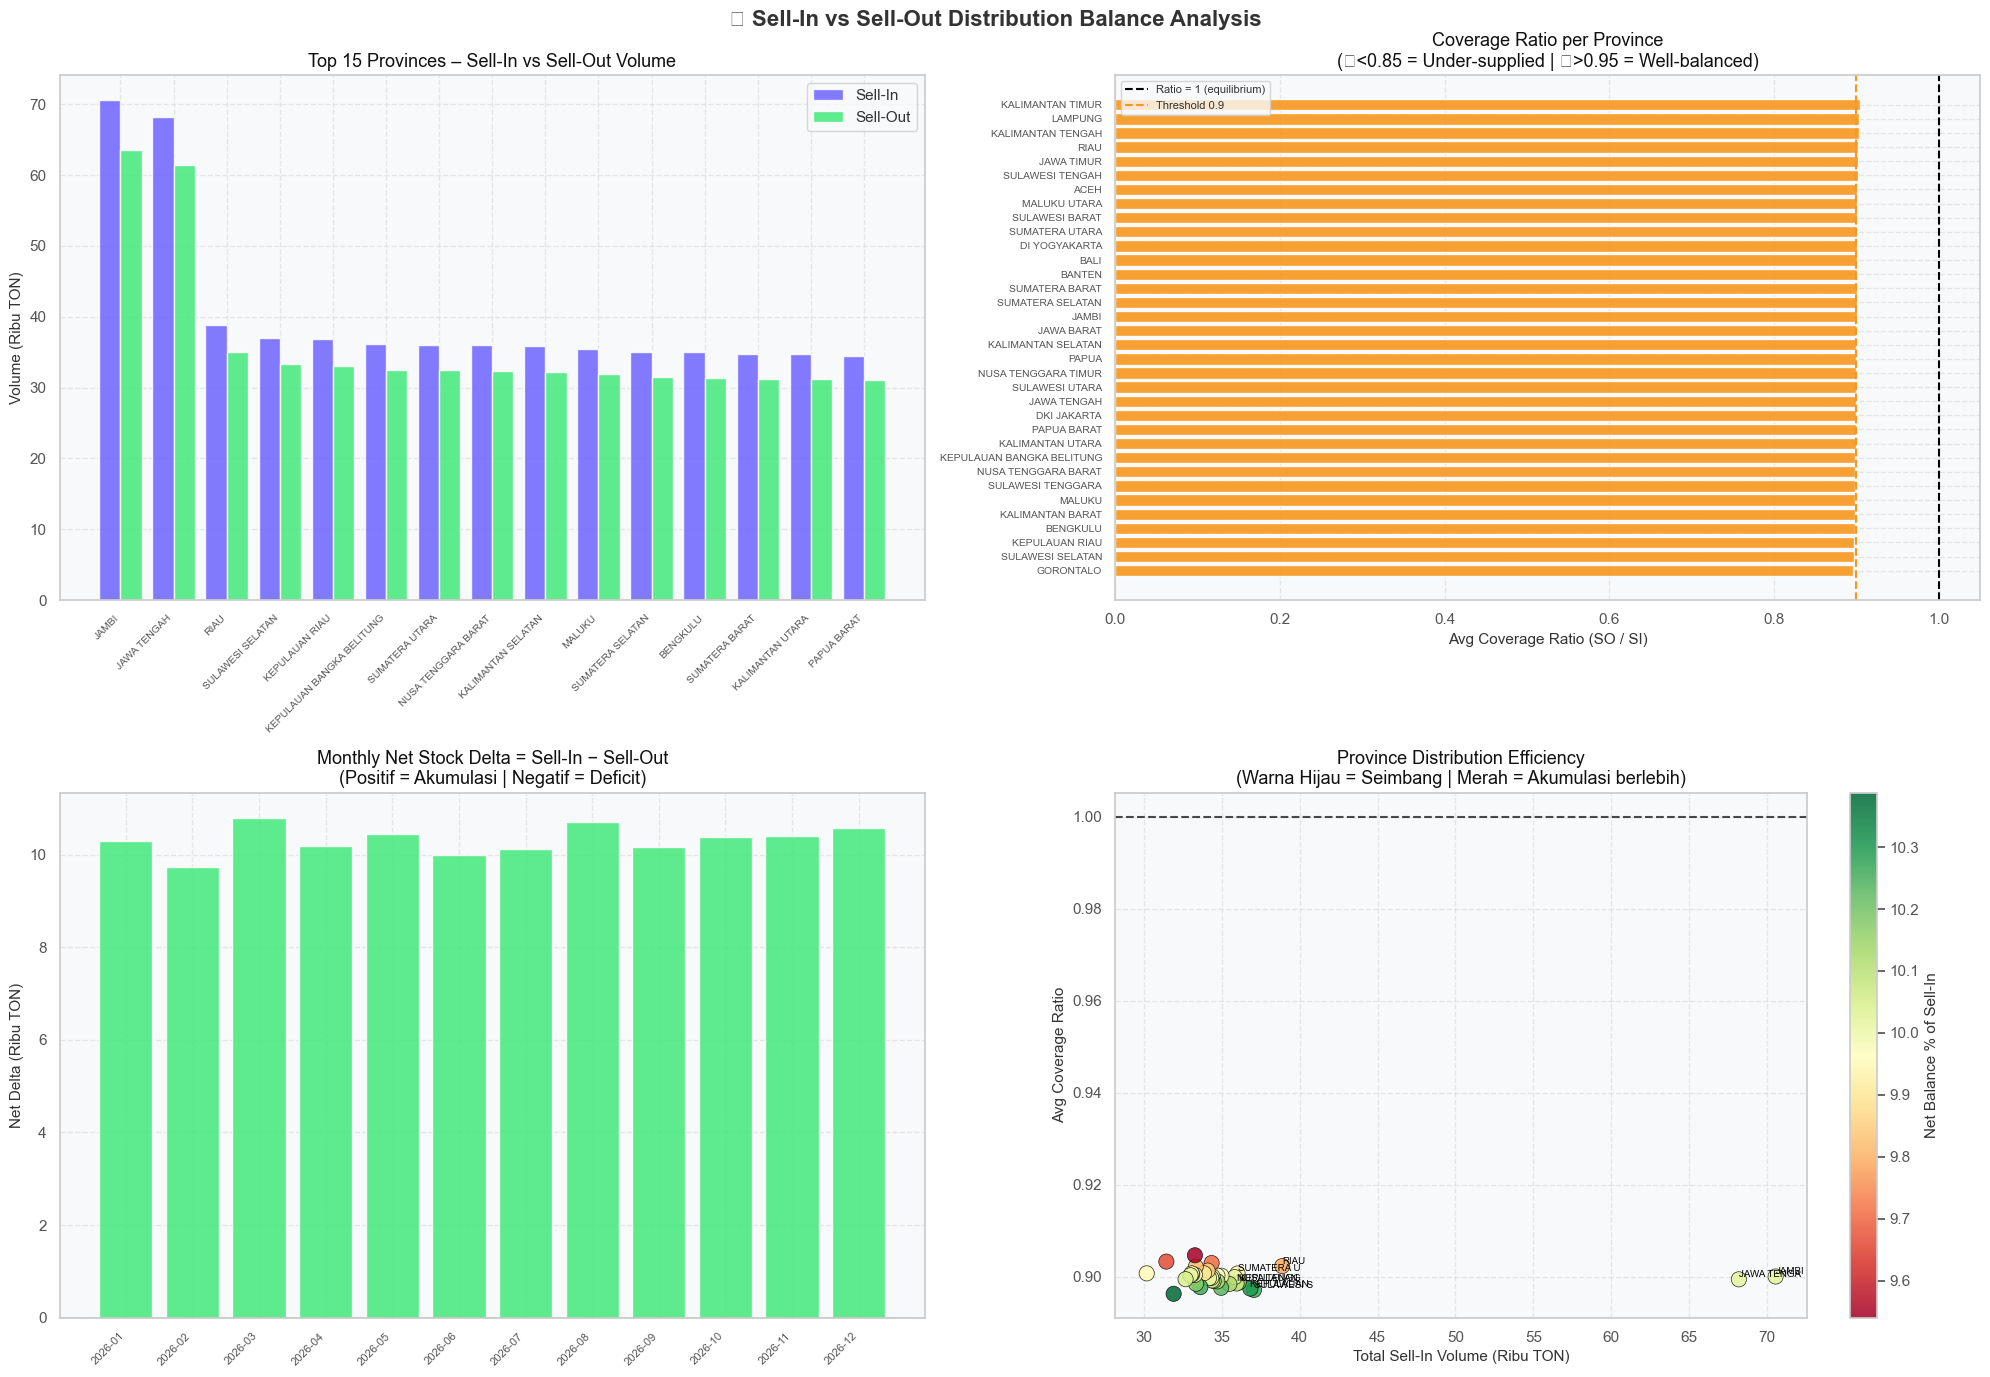

Saved: 15_distribution_balance_analysis.png

  Provinces Analyzed: 34
  Avg Coverage Ratio (all provinces): 0.900
  Under-supplied Provinces (ratio < 0.90): 17
  Over-stocked Provinces (balance > 15%): 0

  Province Coverage Summary (Top 10):
            province_desc  total_si  total_so  avg_coverage  balance_pct
                    JAMBI  70550.96  63479.57      0.900062    10.023095
              JAWA TENGAH  68191.89  61361.69      0.899444    10.016147
                     RIAU  38882.22  35075.20      0.902331     9.791159
         SULAWESI SELATAN  37068.83  33264.59      0.897145    10.262638
           KEPULAUAN RIAU  36840.16  33047.22      0.897436    10.295666
KEPULAUAN BANGKA BELITUNG  36088.93  32416.88      0.898744    10.175004
           SUMATERA UTARA  36018.12  32441.43      0.900716     9.930252
      NUSA TENGGARA BARAT  35953.41  32331.70      0.898547    10.073342
       KALIMANTAN SELATAN  35833.85  32244.31      0.899927    10.017176
                   MALUKU  

In [115]:
# Monthly Sell-In per province
si_prov_monthly = (
    df_sell_in.groupby(["year_month", "province_desc"])["quantity"]
    .sum().reset_index()
)
so_prov_monthly = (
    df_sell_out.groupby(["year_month", "provinsi"])["sum(tonase)"]
    .sum().reset_index()
    .rename(columns={"provinsi": "province_desc", "sum(tonase)": "so_qty"})
)
si_prov_monthly.rename(columns={"quantity": "si_qty"}, inplace=True)

balance_prov = si_prov_monthly.merge(
    so_prov_monthly, on=["year_month", "province_desc"], how="outer"
).fillna(0)
balance_prov["net_delta"] = balance_prov["si_qty"] - balance_prov["so_qty"]
balance_prov["coverage_ratio"] = (
    balance_prov["so_qty"] / balance_prov["si_qty"].replace(0, np.nan)
)

# Aggregate per province
prov_summary = (
    balance_prov.groupby("province_desc")
    .agg(
        total_si=("si_qty", "sum"),
        total_so=("so_qty", "sum"),
        avg_coverage=("coverage_ratio", "mean"),
        net_delta=("net_delta", "sum"),
    )
    .reset_index()
    .sort_values("total_si", ascending=False)
)
prov_summary["balance_pct"] = prov_summary["net_delta"] / prov_summary["total_si"] * 100

# Monthly aggregate for trend
monthly_balance = (
    balance_prov.groupby("year_month")
    .agg(total_si=("si_qty", "sum"), total_so=("so_qty", "sum"))
    .reset_index()
)
monthly_balance["net_delta"] = monthly_balance["total_si"] - monthly_balance["total_so"]
monthly_balance["coverage_ratio"] = monthly_balance["total_so"] / monthly_balance["total_si"]

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("📦 Sell-In vs Sell-Out Distribution Balance Analysis", fontsize=16, fontweight="bold")

# 1. Province Balance: SI vs SO side-by-side (Top 15 provinces)
top15_prov = prov_summary.head(15)
x_idx = np.arange(len(top15_prov))
w = 0.4
bars_si = axes[0, 0].bar(x_idx - w/2, top15_prov["total_si"] / 1e3, w,
                          label="Sell-In", color="#6c63ff", alpha=0.85)
bars_so = axes[0, 0].bar(x_idx + w/2, top15_prov["total_so"] / 1e3, w,
                          label="Sell-Out", color="#43e97b", alpha=0.85)
axes[0, 0].set_xticks(x_idx)
axes[0, 0].set_xticklabels(top15_prov["province_desc"], rotation=45, ha="right", fontsize=7.5)
axes[0, 0].set_ylabel("Volume (Ribu TON)")
axes[0, 0].set_title("Top 15 Provinces – Sell-In vs Sell-Out Volume")
axes[0, 0].legend()

# 2. Coverage Ratio per Province (bar, sorted)
prov_cov = prov_summary.sort_values("avg_coverage", ascending=True)
cov_colors = ["#ff6584" if v < 0.85 else "#f7971e" if v < 0.95 else "#43e97b"
              for v in prov_cov["avg_coverage"]]
axes[0, 1].barh(prov_cov["province_desc"], prov_cov["avg_coverage"],
                color=cov_colors, alpha=0.9)
axes[0, 1].axvline(1.0, color="black", lw=1.5, ls="--", label="Ratio = 1 (equilibrium)")
axes[0, 1].axvline(0.9, color="#f7971e", lw=1.5, ls="--", label="Threshold 0.9")
axes[0, 1].set_xlabel("Avg Coverage Ratio (SO / SI)")
axes[0, 1].set_title("Coverage Ratio per Province\n(🔴<0.85 = Under-supplied | 🟢>0.95 = Well-balanced)")
axes[0, 1].legend(fontsize=8)
axes[0, 1].tick_params(axis="y", labelsize=7.5)

# 3. Monthly Net Delta Trend (Sell-In − Sell-Out)
delta_colors = ["#43e97b" if v >= 0 else "#ff6584" for v in monthly_balance["net_delta"]]
axes[1, 0].bar(monthly_balance["year_month"], monthly_balance["net_delta"] / 1e3,
               color=delta_colors, alpha=0.85)
axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 0].set_ylabel("Net Delta (Ribu TON)")
axes[1, 0].set_title("Monthly Net Stock Delta = Sell-In − Sell-Out\n(Positif = Akumulasi | Negatif = Deficit)")
plt.setp(axes[1, 0].get_xticklabels(), rotation=45, ha="right", fontsize=8)

# 4. Province Balance % Scatter (Over vs Under supplied)
sc = axes[1, 1].scatter(
    prov_summary["total_si"] / 1e3,
    prov_summary["avg_coverage"],
    c=prov_summary["balance_pct"],
    cmap="RdYlGn",
    s=120,
    alpha=0.85,
    edgecolors="black",
    lw=0.5,
)
plt.colorbar(sc, ax=axes[1, 1], label="Net Balance % of Sell-In")
axes[1, 1].axhline(1.0, color="black", lw=1.5, ls="--", alpha=0.7)
axes[1, 1].set_xlabel("Total Sell-In Volume (Ribu TON)")
axes[1, 1].set_ylabel("Avg Coverage Ratio")
axes[1, 1].set_title("Province Distribution Efficiency\n(Warna Hijau = Seimbang | Merah = Akumulasi berlebih)")
for _, row in prov_summary.head(8).iterrows():
    axes[1, 1].annotate(
        row["province_desc"][:10],
        (row["total_si"] / 1e3, row["avg_coverage"]),
        fontsize=7, ha="left", va="bottom", color="black"
    )

plt.tight_layout()
save_fig("15_distribution_balance_analysis")

print(f"\n  Provinces Analyzed: {prov_summary.shape[0]}")
print(f"  Avg Coverage Ratio (all provinces): {prov_summary['avg_coverage'].mean():.3f}")
print(f"  Under-supplied Provinces (ratio < 0.90): {(prov_summary['avg_coverage'] < 0.90).sum()}")
print(f"  Over-stocked Provinces (balance > 15%): {(prov_summary['balance_pct'] > 15).sum()}")
print("\n  Province Coverage Summary (Top 10):")
print(prov_summary[["province_desc","total_si","total_so","avg_coverage","balance_pct"]].head(10).to_string(index=False))


#### Bagian 10 – Analisis Geografis


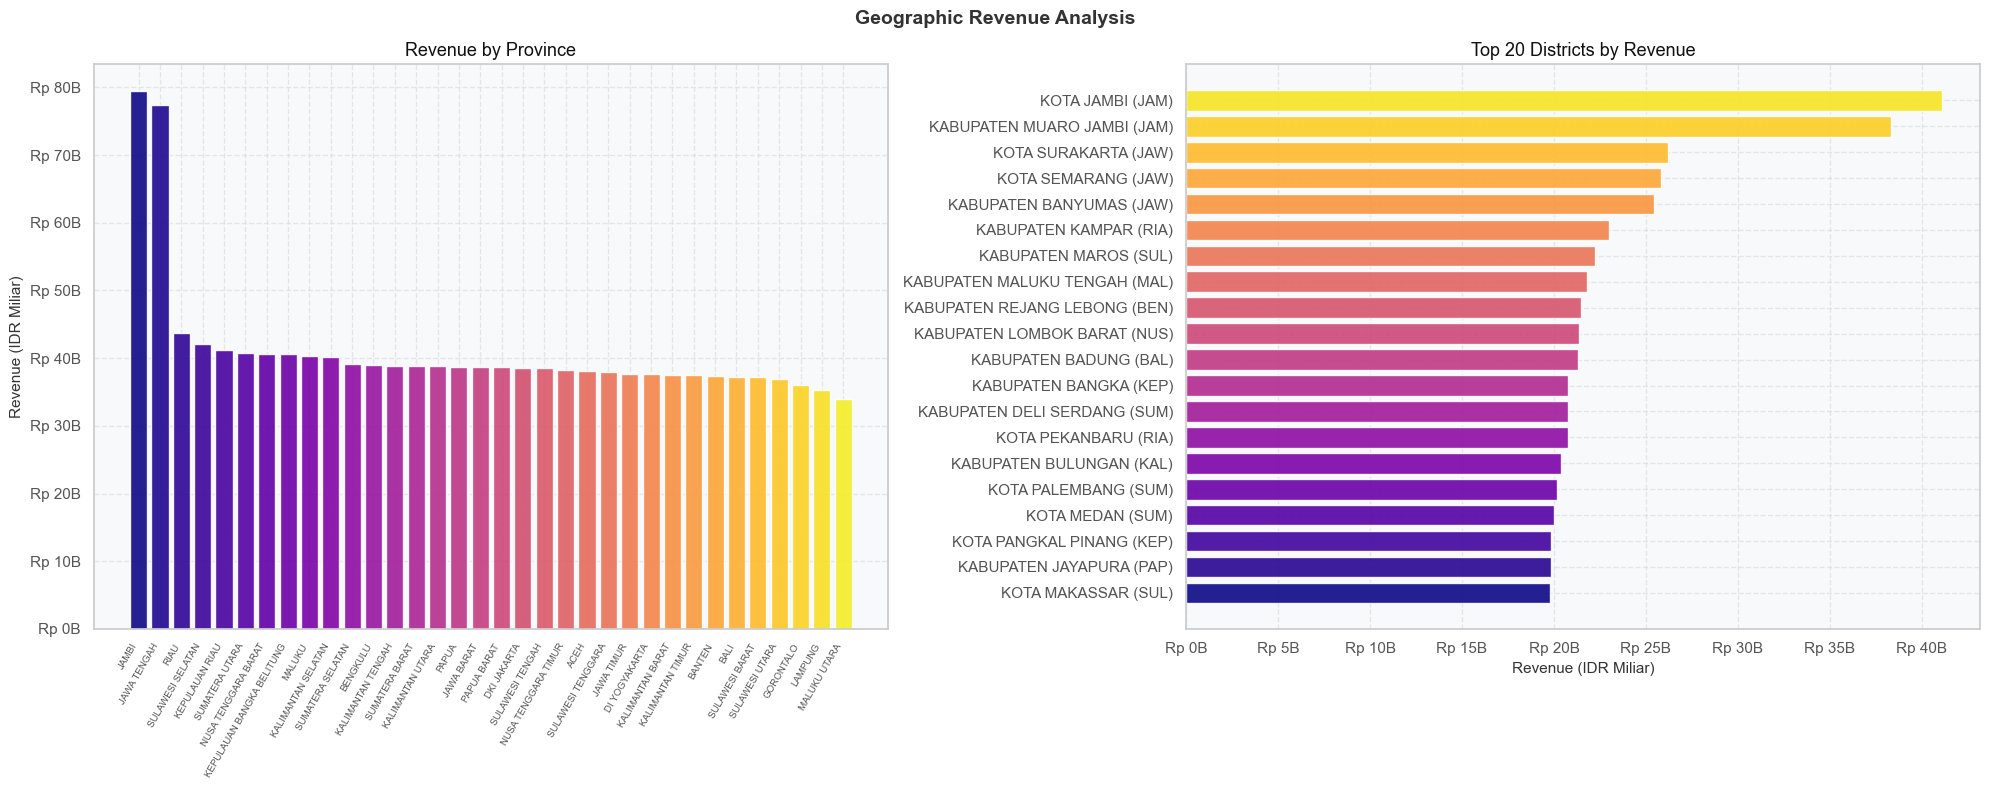

Saved: 16_geographic_analysis.png


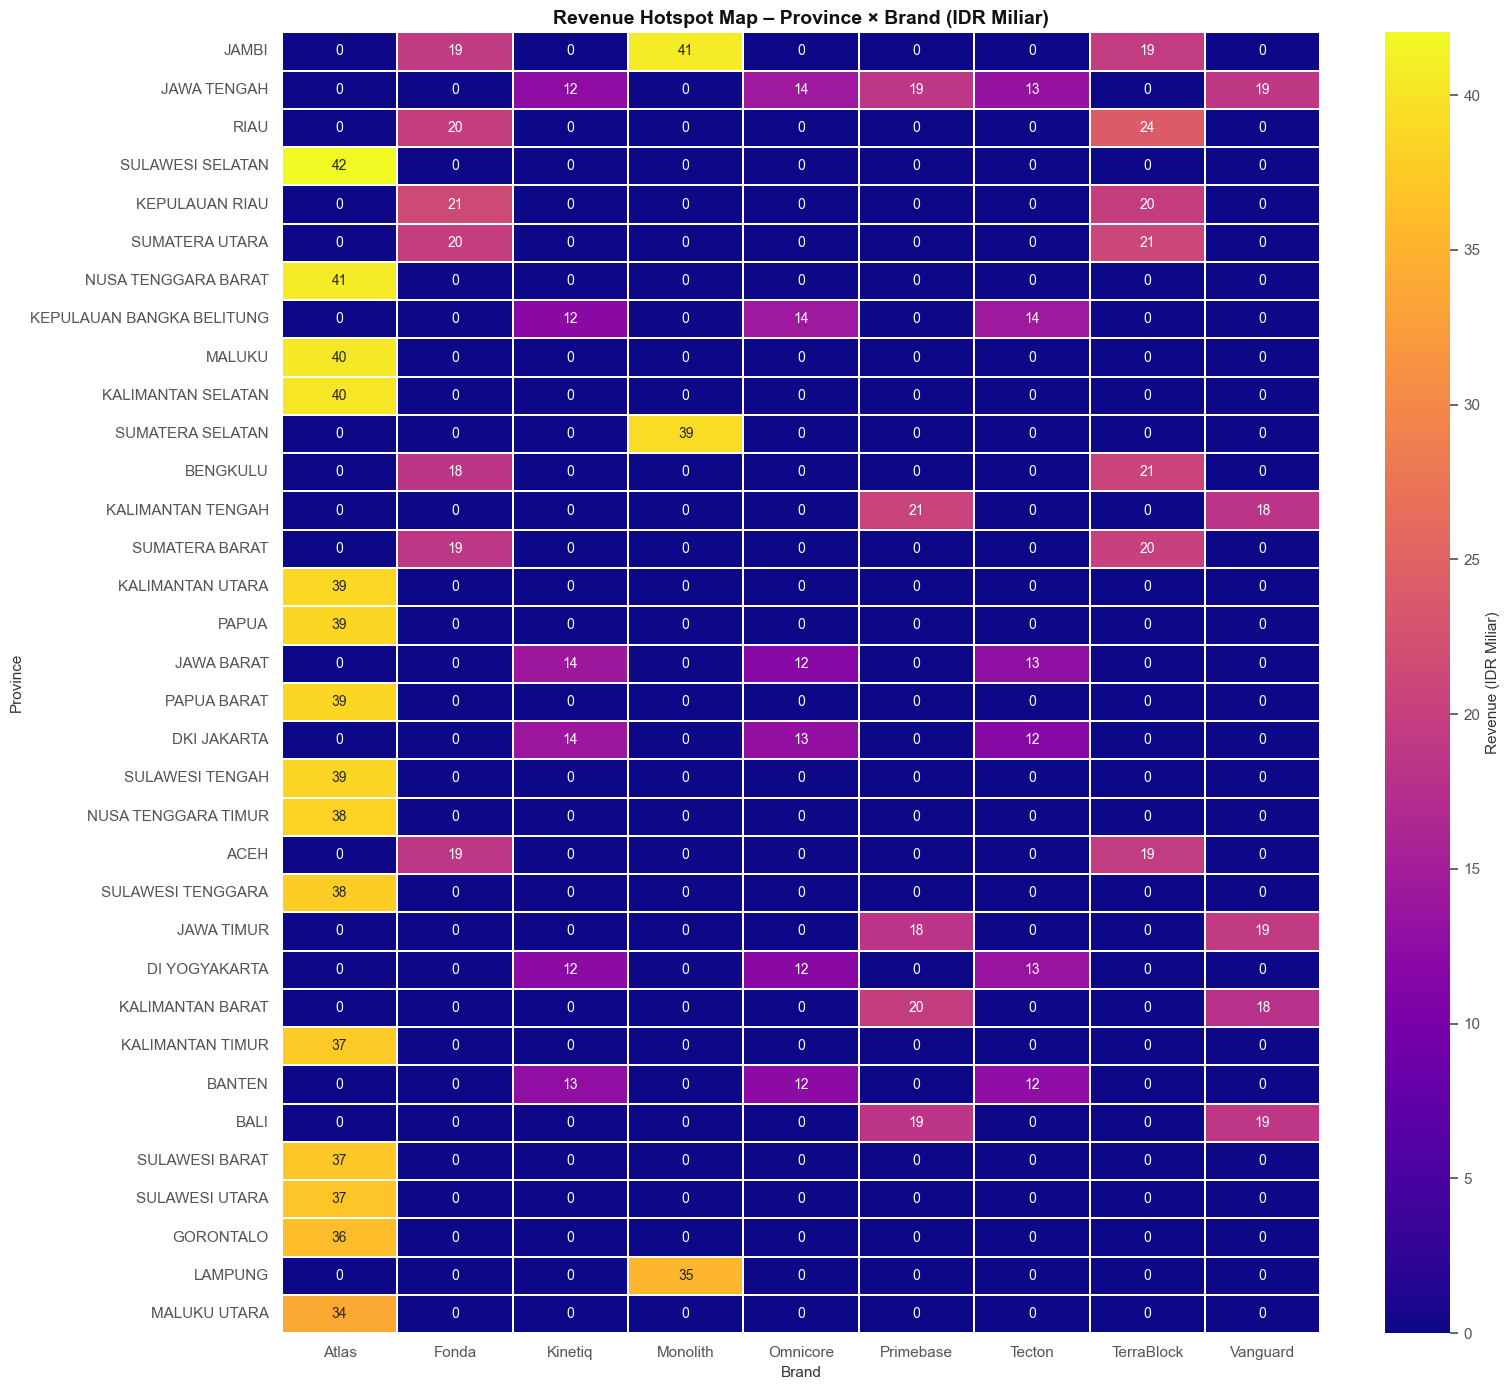

Saved: 17_hotspot_heatmap.png

  Top Province: JAMBI – Rp 79.4B
  Top District: KOTA JAMBI – Rp 41.1B
  Total Provinces: 34


In [116]:
# Province-level summary
geo_prov = (
    df_sell_in.groupby("province_desc")
    .agg(
        total_revenue=("revenue", "sum"),
        total_qty=("quantity", "sum"),
        n_dist=("soldto_desc", "nunique"),
        n_products=("material_desc", "nunique"),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

# District-level summary
geo_dist = (
    df_sell_in.groupby(["province_desc", "district_desc"])
    .agg(
        total_revenue=("revenue", "sum"),
        total_qty=("quantity", "sum"),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Geographic Revenue Analysis", fontsize=14, fontweight="bold")

# Province bar
colors_geo = [GRADIENT(i / len(geo_prov)) for i in range(len(geo_prov))]
bars = axes[0].bar(
    geo_prov["province_desc"],
    geo_prov["total_revenue"] / 1e9,
    color=colors_geo,
    alpha=0.9,
)
axes[0].set_ylabel("Revenue (IDR Miliar)")
axes[0].set_title("Revenue by Province")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}B"))
plt.setp(axes[0].get_xticklabels(), rotation=60, ha="right", fontsize=7)

# Top 20 districts
top20_d = geo_dist.head(20)
axes[1].barh(
    top20_d["district_desc"][::-1]
    + " ("
    + top20_d["province_desc"][::-1].str[:3]
    + ")",
    top20_d["total_revenue"][::-1] / 1e9,
    color=[GRADIENT(i / 20) for i in range(20)],
    alpha=0.9,
)
axes[1].set_xlabel("Revenue (IDR Miliar)")
axes[1].set_title("Top 20 Districts by Revenue")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}B"))

plt.tight_layout()
save_fig("16_geographic_analysis")

# Hotspot heatmap (Province × Brand)
hotspot = df_sell_in.groupby(["province_desc", "brand"])["revenue"].sum().reset_index()
hotspot_pivot = hotspot.pivot(
    index="province_desc", columns="brand", values="revenue"
).fillna(0)
hotspot_pivot = hotspot_pivot.loc[
    hotspot_pivot.sum(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    hotspot_pivot / 1e9,
    annot=True,
    fmt=".0f",
    cmap="plasma",
    ax=ax,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Revenue (IDR Miliar)"},
)
ax.set_title(
    "Revenue Hotspot Map – Province × Brand (IDR Miliar)",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Brand")
ax.set_ylabel("Province")
plt.tight_layout()
save_fig("17_hotspot_heatmap")

print(
    f"\n  Top Province: {geo_prov.iloc[0]['province_desc']} – {fmt_idr(geo_prov.iloc[0]['total_revenue'])}"
)
print(
    f"  Top District: {geo_dist.iloc[0]['district_desc']} – {fmt_idr(geo_dist.iloc[0]['total_revenue'])}"
)
print(f"  Total Provinces: {geo_prov.shape[0]}")


#### Bagian 11 – Analisis Survey Mendalam


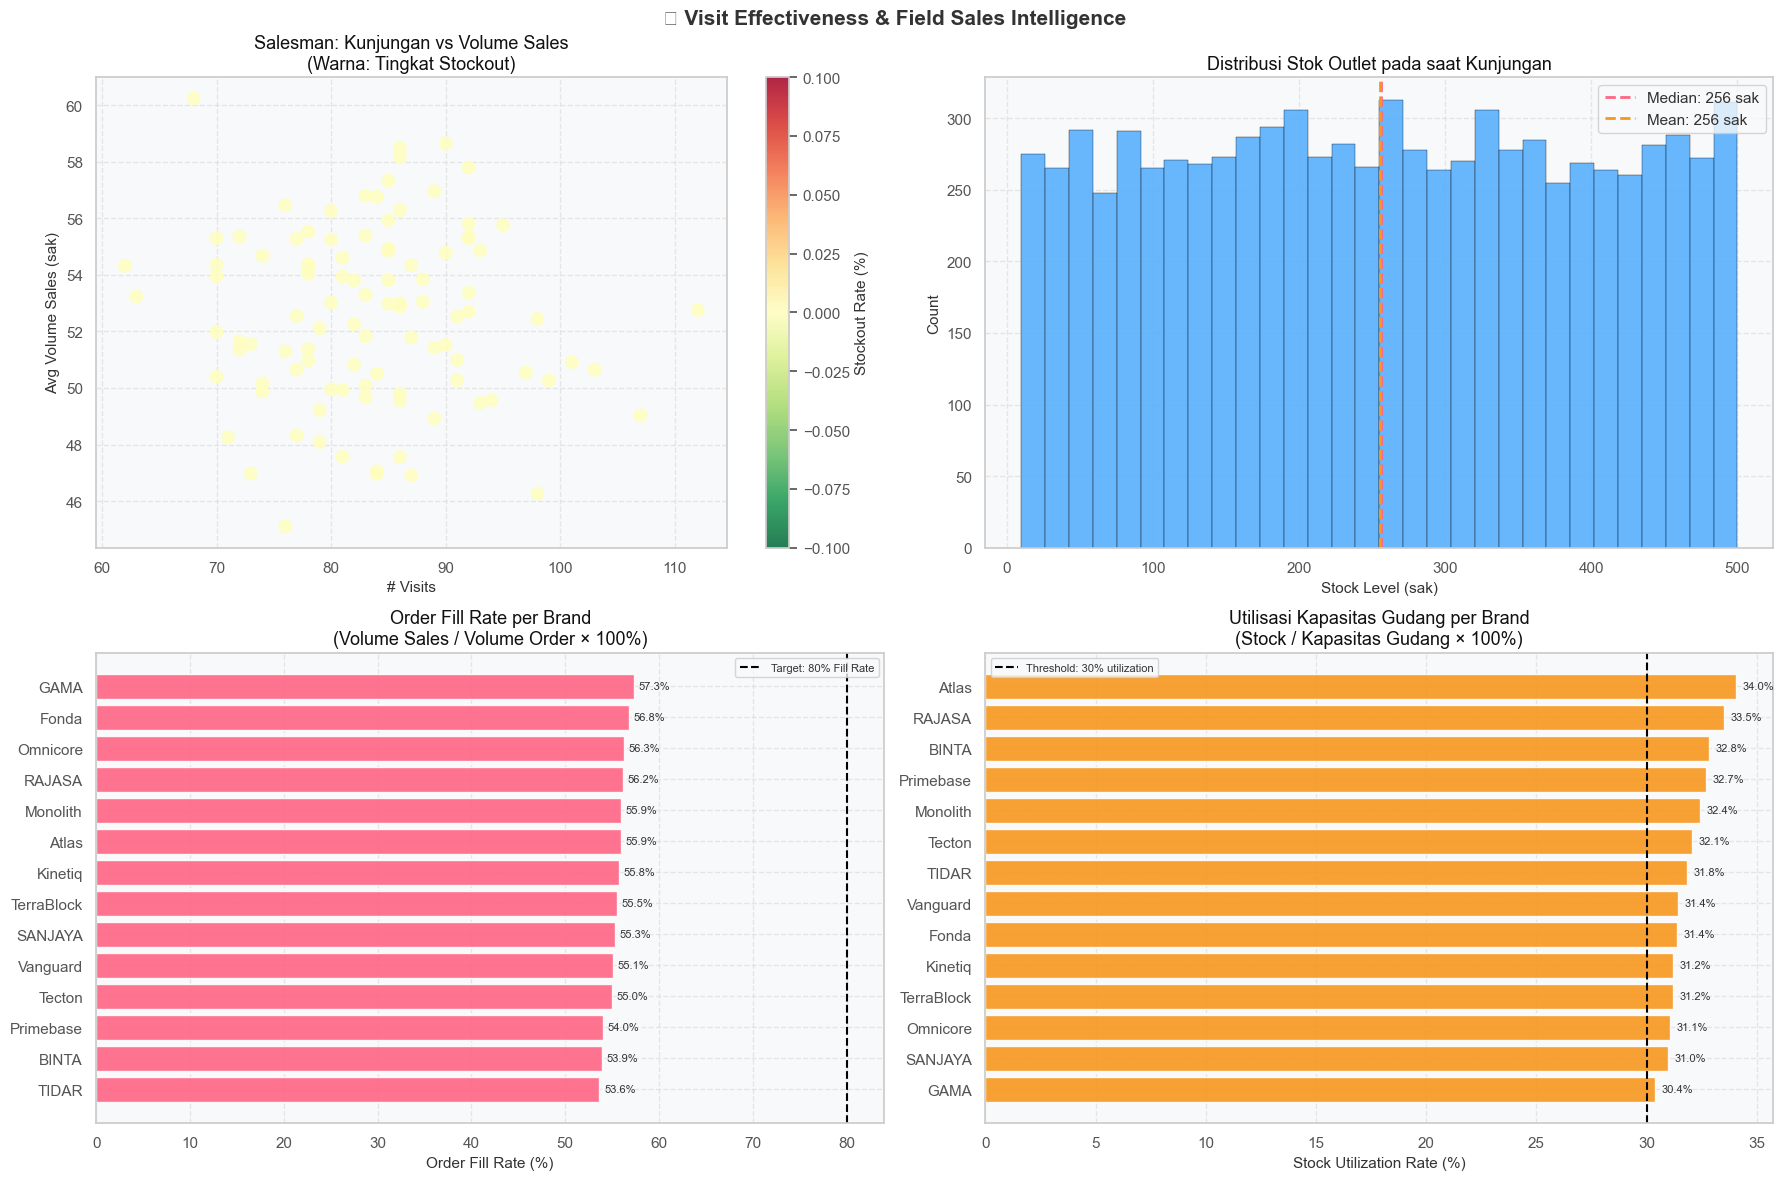

Saved: 18_survey_effectiveness.png

  Total Survey Visits: 8,350
  Avg Order Fill Rate: 55.5%
  Avg Stock Utilization: 31.9%
  Avg Visit Volume Sales: 52.5 sak
  Avg Visit Duration: 30.0 minutes


In [ ]:
# Visit effectiveness by salesman
if "stock_available" not in df_survey.columns:
    df_survey["stock_available"] = df_survey["stock"] > 0
if "visit_duration" not in df_survey.columns:
    checkin_dt = pd.to_datetime(df_survey["checkin_time"], format="%H:%M:%S", errors="coerce")
    checkout_dt = pd.to_datetime(df_survey["checkout_time"], format="%H:%M:%S", errors="coerce")
    df_survey["visit_duration"] = (checkout_dt - checkin_dt).dt.total_seconds() / 60.0

salesman_perf = (
    df_survey.groupby("salesman")
    .agg(
        n_visits=("no_survey", "count"),
        avg_volume_sales=("volume_sales", "mean"),
        avg_stock=("stock", "mean"),
        stockout_rate=("stock_available", lambda x: (1 - x.mean()) * 100),
    )
    .reset_index()
    .sort_values("avg_volume_sales", ascending=False)
)

# Order Fill Rate = volume_sales / volume_order (seberapa banyak pesanan yang terpenuhi)
df_survey["fill_rate"] = (df_survey["volume_sales"] / df_survey["volume_order"].replace(0, np.nan) * 100).clip(0, 100)

# Stock Utilization = stock / kapasitas_gudang
df_survey["stock_utilization"] = (df_survey["stock"] / df_survey["kapasitas_gudang"].replace(0, np.nan) * 100).clip(0, 150)

fill_by_brand = (
    df_survey.groupby("brand")["fill_rate"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
util_by_brand = (
    df_survey.groupby("brand")["stock_utilization"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("👤 Visit Effectiveness & Field Sales Intelligence", fontsize=15, fontweight="bold")

# 1. Salesman: Visits vs Avg Volume Sales (scatter colored by stockout rate)
sc = axes[0, 0].scatter(
    salesman_perf["n_visits"],
    salesman_perf["avg_volume_sales"],
    c=salesman_perf["stockout_rate"],
    cmap="RdYlGn_r",
    s=80,
    alpha=0.85,
)
plt.colorbar(sc, ax=axes[0, 0], label="Stockout Rate (%)")
axes[0, 0].set_xlabel("# Visits")
axes[0, 0].set_ylabel("Avg Volume Sales (sak)")
axes[0, 0].set_title("Salesman: Kunjungan vs Volume Sales\n(Warna: Tingkat Stockout)")

# 2. Stock Level Distribution at Outlet
axes[0, 1].hist(
    df_survey["stock"].clip(0, 500),
    bins=30,
    color="#4facfe",
    alpha=0.85,
    edgecolor="black",
    lw=0.3,
)
axes[0, 1].axvline(
    df_survey["stock"].median(),
    color="#ff6584",
    lw=2,
    ls="--",
    label=f"Median: {df_survey['stock'].median():.0f} sak",
)
axes[0, 1].axvline(
    df_survey["stock"].mean(),
    color="#f7971e",
    lw=2,
    ls="--",
    label=f"Mean: {df_survey['stock'].mean():.0f} sak",
)
axes[0, 1].set_xlabel("Stock Level (sak)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribusi Stok Outlet pada saat Kunjungan")
axes[0, 1].legend()

# 3. Order Fill Rate by Brand (volume_sales / volume_order)
fill_colors = ["#43e97b" if v >= 80 else "#f7971e" if v >= 60 else "#ff6584"
               for v in fill_by_brand["fill_rate"]]
bars = axes[1, 0].barh(
    fill_by_brand["brand"][::-1],
    fill_by_brand["fill_rate"][::-1],
    color=fill_colors[::-1],
    alpha=0.9,
)
axes[1, 0].axvline(80, color="black", lw=1.5, ls="--", label="Target: 80% Fill Rate")
axes[1, 0].set_xlabel("Order Fill Rate (%)")
axes[1, 0].set_title("Order Fill Rate per Brand\n(Volume Sales / Volume Order × 100%)")
axes[1, 0].legend(fontsize=8)
for bar, val in zip(bars, fill_by_brand["fill_rate"][::-1].values):
    axes[1, 0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%", va="center", fontsize=8)

# 4. Stock Utilization Rate by Brand (stock / kapasitas_gudang)
util_colors = ["#ff6584" if v < 20 else "#f7971e" if v < 40 else "#43e97b"
               for v in util_by_brand["stock_utilization"]]
bars2 = axes[1, 1].barh(
    util_by_brand["brand"],
    util_by_brand["stock_utilization"],
    color=util_colors,
    alpha=0.9,
)
axes[1, 1].axvline(30, color="black", lw=1.5, ls="--", label="Threshold: 30% utilization")
axes[1, 1].set_xlabel("Stock Utilization Rate (%)")
axes[1, 1].set_title("Utilisasi Kapasitas Gudang per Brand\n(Stock / Kapasitas Gudang × 100%)")
axes[1, 1].legend(fontsize=8)
for bar, val in zip(bars2, util_by_brand["stock_utilization"].values):
    axes[1, 1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%", va="center", fontsize=8)

plt.tight_layout()
save_fig("18_survey_effectiveness")

print(f"\n  Total Survey Visits: {df_survey.shape[0]:,}")
print(f"  Avg Order Fill Rate: {df_survey['fill_rate'].mean():.1f}%")
print(f"  Avg Stock Utilization: {df_survey['stock_utilization'].mean():.1f}%")
print(f"  Avg Visit Volume Sales: {df_survey['volume_sales'].mean():.1f} sak")
print(f"  Avg Visit Duration: {df_survey['visit_duration'].median():.1f} minutes")

#### Bagian 12 – Membuat Agregasi Untuk Dashboard

##### fact_revenue


In [118]:
fact_revenue = (
    df_sell_in.groupby(
        [
            "year_month",
            "province_desc",
            "district_desc",
            "brand",
            "material_desc",
            "soldto_desc",
            "segment",
        ]
    )
    .agg(
        total_revenue=("revenue", "sum"),
        total_quantity=("quantity", "sum"),
        avg_price_per_ton=("revenue", "mean"),
        n_transactions=("revenue", "count"),
    )
    .reset_index()
)
fact_revenue["year"] = fact_revenue["year_month"].str[:4].astype(int)
fact_revenue["month"] = fact_revenue["year_month"].str[5:].astype(int)
fact_revenue.to_csv(os.path.join(OUTPUT_DIR, "fact_revenue.csv"), index=False)
print(
    f"\nfact_revenue.csv        → {len(fact_revenue):,} rows × {len(fact_revenue.columns)} cols"
)



fact_revenue.csv        → 12,324 rows × 13 cols


##### fact_inventory


In [119]:
fact_inventory = balance_prov.copy()
fact_inventory.to_csv(os.path.join(OUTPUT_DIR, "fact_inventory.csv"), index=False)
print(
    f"  fact_inventory.csv      -> {len(fact_inventory):,} rows x {len(fact_inventory.columns)} cols"
)

  fact_inventory.csv      -> 408 rows x 6 cols


##### fact_distributor


In [120]:
fact_distributor = (
    df_sell_in.groupby(["soldto_desc", "province_desc", "year_month"])
    .agg(
        total_revenue=("revenue", "sum"),
        total_qty=("quantity", "sum"),
        n_products=("material_desc", "nunique"),
        n_transactions=("revenue", "count"),
    )
    .reset_index()
)
fact_distributor["year"] = fact_distributor["year_month"].str[:4].astype(int)
fact_distributor["month"] = fact_distributor["year_month"].str[5:].astype(int)
fact_distributor.to_csv(os.path.join(OUTPUT_DIR, "fact_distributor.csv"), index=False)
print(
    f"fact_distributor.csv    → {len(fact_distributor):,} rows × {len(fact_distributor.columns)} cols"
)


fact_distributor.csv    → 1,224 rows × 9 cols


##### fact_outlet


In [121]:
fact_outlet = (
    df_sell_out.groupby(
        [
            "kode_toko",
            "nama_toko",
            "kode_gudang",
            "nama_gudang",
            "kode_distributor",
            "provinsi",
            "year_month",
        ]
    )
    .agg(
        total_volume=("sum(tonase)", "sum"),
        n_transactions=("sum(tonase)", "count"),
        avg_daily_vol=("sum(tonase)", "mean"),
    )
    .reset_index()
)
fact_outlet["year"] = fact_outlet["year_month"].str[:4].astype(int)
fact_outlet["month"] = fact_outlet["year_month"].str[5:].astype(int)
fact_outlet.to_csv(os.path.join(OUTPUT_DIR, "fact_outlet.csv"), index=False)
print(
    f"fact_outlet.csv         → {len(fact_outlet):,} rows × {len(fact_outlet.columns)} cols"
)


fact_outlet.csv         → 13,309 rows × 12 cols


##### fact_product


In [122]:
fact_product = (
    df_sell_in.groupby(["material_desc", "material_code", "brand", "year_month"])
    .agg(
        total_revenue=("revenue", "sum"),
        total_qty=("quantity", "sum"),
        n_distributors=("soldto_desc", "nunique"),
        n_provinces=("province_desc", "nunique"),
        n_transactions=("revenue", "count"),
    )
    .reset_index()
)
fact_product["year"] = fact_product["year_month"].str[:4].astype(int)
fact_product["month"] = fact_product["year_month"].str[5:].astype(int)
fact_product.to_csv(os.path.join(OUTPUT_DIR, "fact_product.csv"), index=False)
print(
    f"fact_product.csv        → {len(fact_product):,} rows × {len(fact_product.columns)} cols"
)


fact_product.csv        → 432 rows × 11 cols


###### dim_survey


In [123]:
dim_survey = (
    df_survey.groupby(
        [
            "customer_code",
            "customer_name",
            "cluster_name",
            "provinsi",
            "kabupaten",
            "distributor_code",
            "distributor_name",
            "salesman",
            "brand",
            "brand_group",
            "year_month",
        ]
    )
    .agg(
        total_volume_sales=("volume_sales", "sum"),
        total_volume_order=("volume_order", "sum"),
        avg_stock=("stock", "mean"),
        stockout_rate=("stock_available", lambda x: (1 - x.mean()) * 100),
        avg_fill_rate=("fill_rate", "mean"),     # Pengganti order_conv_rate yg selalu 100%
        avg_stock_utilization=("stock_utilization", "mean"),
        n_visits=("no_survey", "count"),
        avg_visit_dur_min=("visit_duration", "mean"),
    )
    .reset_index()
)
dim_survey["year"] = dim_survey["year_month"].str[:4].astype(int)
dim_survey["month"] = dim_survey["year_month"].str[5:].astype(int)
dim_survey.to_csv(os.path.join(OUTPUT_DIR, "dim_survey.csv"), index=False)
print(
    f"dim_survey.csv          -> {len(dim_survey):,} rows x {len(dim_survey.columns)} cols"
)
print("  Columns:", list(dim_survey.columns))


dim_survey.csv          -> 8,347 rows x 21 cols
  Columns: ['customer_code', 'customer_name', 'cluster_name', 'provinsi', 'kabupaten', 'distributor_code', 'distributor_name', 'salesman', 'brand', 'brand_group', 'year_month', 'total_volume_sales', 'total_volume_order', 'avg_stock', 'stockout_rate', 'avg_fill_rate', 'avg_stock_utilization', 'n_visits', 'avg_visit_dur_min', 'year', 'month']


#### Bagian 13 – Kesimpulan


In [124]:
total_revenue = df_sell_in["revenue"].sum()
best_brand = rev_brand.idxmax()
top_prov = geo_prov.iloc[0]["province_desc"]
top_dist_n = n_80pct
stockout_rate = (df_survey["stock"] == 0).mean() * 100
fill_rate_avg = df_survey["fill_rate"].mean()

# Distribution balance metrics from prov_summary
under_supplied = (prov_summary["avg_coverage"] < 0.90).sum()
avg_coverage = prov_summary["avg_coverage"].mean()
net_stock_delta = monthly_balance["net_delta"].sum()

summary = f"""
======================================================================
EXECUTIVE SUMMARY - SIG EDA FINDINGS
======================================================================

REVENUE:
- Total Revenue Sell-In: {fmt_idr(total_revenue)}
- Best Performing Brand: {best_brand}
- #1 Province:  {top_prov}
- Revenue Growth: See monthly trend chart

PARETO RULE (80/20):
- Top {top_dist_n} distributors generate 80% of total revenue
- Action: Focus retention & support on these {top_dist_n} distributors

DISTRIBUTION BALANCE:
- Avg Coverage Ratio (SO/SI): {avg_coverage:.3f}
- Under-supplied Provinces (ratio < 0.90): {under_supplied}
- Net Stock Accumulation (Sell-In - Sell-Out): {net_stock_delta:,.0f} TON
- Action: Re-balance distribution to under-supplied provinces

SURVEY / FIELD:
- Stockout Rate: {stockout_rate:.1f}% of outlet visits
- Avg Order Fill Rate: {fill_rate_avg:.1f}%
- Action: Improve field restocking frequency & order fulfillment

STRATEGIC RECOMMENDATIONS:
1. Consolidate distributor support to Pareto-20 group
2. Re-route stock allocation to under-supplied provinces
3. Increase visit frequency in high-stockout provinces
4. Launch slow-moving product promotions to clear overstock
5. Monitor Coverage Ratio daily via Power BI real-time dashboard
======================================================================
"""
print(summary)

with open(
    os.path.join(OUTPUT_DIR, "Executive_Summary.txt"), "w", encoding="utf-8"
) as f:
    f.write(summary)
print("  Saved: Executive_Summary.txt")



EXECUTIVE SUMMARY - SIG EDA FINDINGS

REVENUE:
- Total Revenue Sell-In: Rp 1.4T
- Best Performing Brand: Atlas
- #1 Province:  JAMBI
- Revenue Growth: See monthly trend chart

PARETO RULE (80/20):
- Top 78 distributors generate 80% of total revenue
- Action: Focus retention & support on these 78 distributors

DISTRIBUTION BALANCE:
- Avg Coverage Ratio (SO/SI): 0.900
- Under-supplied Provinces (ratio < 0.90): 17
- Net Stock Accumulation (Sell-In - Sell-Out): 123,808 TON
- Action: Re-balance distribution to under-supplied provinces

SURVEY / FIELD:
- Stockout Rate: 0.0% of outlet visits
- Avg Order Fill Rate: 55.5%
- Action: Improve field restocking frequency & order fulfillment

STRATEGIC RECOMMENDATIONS:
1. Consolidate distributor support to Pareto-20 group
2. Re-route stock allocation to under-supplied provinces
3. Increase visit frequency in high-stockout provinces
4. Launch slow-moving product promotions to clear overstock
5. Monitor Coverage Ratio daily via Power BI real-time dash